# Paper Figures (clean)

This notebook generates the overview figure, a UMAP with centroid labels, and dotplots for fibro/keratinocyte markers. It is robust to missing files and will tell you which sources it used.

In [1]:
# Cell 1 — setup & helpers
from __future__ import annotations
import os, sys, re, json, math, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# optional (only needed for UMAP & dotplots)
try:
    import scanpy as sc
except Exception:
    sc = None

# --- find repo ROOT robustly ---
def find_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(8):
        if (cur / ".git").exists() or (cur / "README.md").exists():
            return cur
        cur = cur.parent
    return start.resolve()

NB_DIR = Path.cwd()
ROOT   = find_root(NB_DIR)
print("[OK] Using repo root:", ROOT)

def rel(*p): 
    return (ROOT / Path(*p)).resolve()

# small display helper
def note(msg): 
    print(msg if msg.endswith("\n") else msg)


[OK] Using repo root: /home/glen/scleroderma-scvi


In [2]:
# Cell 2 — IO helpers

def read_first_csv(candidates):
    tried = []
    for path in candidates:
        p = Path(path)
        tried.append(str(p))
        if p.exists():
            print(f"[OK] Loaded: {p}")
            return pd.read_csv(p)
    raise FileNotFoundError("None of these files were found:\n  - " + "\n  - ".join(tried))

def first_existing(paths):
    for p in map(Path, paths):
        if p.exists():
            return p
    return None

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p


## Figure 1: Overview (priority bar + heatmap + selectivity vs breadth)

In [3]:
# Cell 3 — Figure 1 (overview)

# candidate locations (works across your past runs)
final_candidates = [
    rel("results/drug_repurposing/final_shortlist_ranked.csv"),
    rel("results/drug_repurposing/final_bundle/final_shortlist_ranked.csv"),
    rel("results/drug_repurposing/deliverable_20250922/final_shortlist_ranked.csv"),
]
top15_candidates = [
    rel("results/drug_repurposing/lincs_reversal_top15_by_cluster.csv"),
    rel("results/drug_repurposing/final_bundle/lincs_reversal_top15_by_cluster.csv"),
    rel("results/drug_repurposing/deliverable_20250922/lincs_reversal_top15_by_cluster.csv"),
]
spec_candidates = [
    rel("results/drug_repurposing/shortlist_fibro_with_specificity.csv"),
    rel("results/drug_repurposing/final_bundle/shortlist_fibro_with_specificity.csv"),
    rel("results/drug_repurposing/deliverable_20250922/shortlist_fibro_with_specificity.csv"),
]

final = read_first_csv(final_candidates)
top15 = read_first_csv(top15_candidates)
spec  = first_existing(spec_candidates)
spec  = pd.read_csv(spec) if spec else None

# choose top N by final composite
TOPN = 12
top = final.sort_values("priority_final", ascending=False).head(TOPN).copy()
bases = top["base_compound"].tolist()

def base_filter(df, base):
    return df[df["compound"].str.contains(str(base), case=False, regex=False)]

def breadth_from_top15(df_for_base, rev_col="rev_score_max", thr=12.0):
    if df_for_base.empty: return 0
    s = df_for_base.groupby("cell_type")[rev_col].max()
    return int((s >= thr).sum())

def fibro_like(name: str) -> bool:
    name = (name or "").lower()
    return ("fibroblast" in name) or ("myofibro" in name)

def selectivity_mean_of_max(df_for_base, rev_col="rev_score_max"):
    if df_for_base.empty: return np.nan
    g = df_for_base.groupby("cell_type")[rev_col].max()
    if g.empty: return np.nan
    idx = pd.Index(g.index.astype(str))
    fib_mask = idx.to_series().apply(fibro_like).values
    fib_vals  = g[fib_mask].astype(float)
    non_vals  = g[~fib_mask].astype(float)
    if fib_vals.size == 0 or non_vals.size == 0:
        return np.nan
    return float(np.nanmean(fib_vals) - np.nanmean(non_vals))

# Panel B pivot: max LINCS reversal by (base × cell_type)
sub = []
for b in bases:
    rows = base_filter(top15, b).copy()
    if rows.empty: 
        continue
    tmp = (rows.groupby(["compound","cell_type"])["rev_score_max"]
               .max()
               .reset_index())
    tmp["base_compound"] = b
    sub.append(tmp)
piv = None
if sub:
    sub = pd.concat(sub, ignore_index=True)
    piv = (sub.groupby(["base_compound","cell_type"])["rev_score_max"]
              .max().reset_index()
              .pivot(index="base_compound", columns="cell_type", values="rev_score_max")
              .reindex(index=bases))
    if piv.shape[1] > 0:
        piv = piv[piv.mean(0).sort_values(ascending=False).index]

# Selectivity/breadth
sel_vals = {}
brd_vals = {}
for b in bases:
    dfb = base_filter(top15, b)
    if spec is not None and "fibro_selectivity" in spec.columns:
        row = spec[spec["base_compound"].str.lower()==str(b).lower()]
        sel = float(row["fibro_selectivity"].iloc[0]) if not row.empty else selectivity_mean_of_max(dfb)
    else:
        sel = selectivity_mean_of_max(dfb)
    sel_vals[b] = sel
    brd_vals[b] = breadth_from_top15(dfb)

# --- draw figure
from matplotlib.colors import TwoSlopeNorm

fig = plt.figure(figsize=(10.5, 4.8), dpi=150)
gs  = fig.add_gridspec(nrows=2, ncols=8, height_ratios=[1,1], wspace=1.0, hspace=0.8)

# A: composite priority
axA = fig.add_subplot(gs[:, 0:2])
bar = top.iloc[::-1]
axA.barh(bar["base_compound"], bar["priority_final"])
axA.set_title("(A) Composite priority", loc="left", fontweight="bold")
axA.set_xlabel("Priority score")
axA.set_ylabel("")
for i, v in enumerate(bar["priority_final"].values):
    axA.text(v, i, f"{v:.1f}", va="center", ha="left", fontsize=7)

# B: heatmap of max reversal (center scale only if range crosses 0)
axB = fig.add_subplot(gs[0, 3:6])
if piv is not None and piv.size:
    vmin = np.nanmin(piv.values); vmax = np.nanmax(piv.values)
    if vmin < 0 < vmax:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        im = axB.imshow(piv.values, aspect="auto", norm=norm, cmap="RdBu_r")
    else:
        im = axB.imshow(piv.values, aspect="auto")
    axB.set_yticks(range(len(piv.index)));  axB.set_yticklabels(piv.index, fontsize=8)
    step = max(1, max(1, piv.shape[1] // 10))
    xticks = list(range(0, piv.shape[1], step))
    axB.set_xticks(xticks); 
    axB.set_xticklabels([str(piv.columns[i]) for i in xticks], rotation=60, ha="right", fontsize=7)
    axB.set_title("(B) Max reversal by cell type", loc="left", fontweight="bold")
    cbar = plt.colorbar(im, ax=axB, fraction=0.05, pad=0.04)
    cbar.set_label("Reversal score (LINCS)")
else:
    axB.axis("off"); axB.text(0.5,0.5,"No LINCS rows for selected compounds", ha="center")

# C: selectivity vs breadth
axC = fig.add_subplot(gs[1, 3:6])
xs = [brd_vals[b] for b in bases]
ys = [sel_vals[b] for b in bases]
axC.scatter(xs, ys)
for x, y, label in zip(xs, ys, bases):
    axC.annotate(label, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=7)
axC.axhline(0, color="k", linewidth=0.6)
axC.set_xlabel("Breadth (cell types with reversal ≥ 12)")
axC.set_ylabel("Fibro selectivity (mean max fibro − mean max others)")
axC.set_title("(C) Selectivity vs breadth", loc="left", fontweight="bold")

# save
OUTF = ensure_dir(rel("results/figures"))
png = OUTF / "fig_overview.png"
pdf = OUTF / "fig_overview.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, dpi=300, bbox_inches="tight")
plt.close(fig)
print("[saved]", png)
print("[saved]", pdf)


[OK] Loaded: /home/glen/scleroderma-scvi/results/drug_repurposing/final_shortlist_ranked.csv
[OK] Loaded: /home/glen/scleroderma-scvi/results/drug_repurposing/lincs_reversal_top15_by_cluster.csv


[saved] /home/glen/scleroderma-scvi/results/figures/fig_overview.png
[saved] /home/glen/scleroderma-scvi/results/figures/fig_overview.pdf


## Figure 2: UMAP with centroid labels (de-cluttered)

In [4]:
# Cell 4 — Figure 2 (QC + clustering)

if sc is None:
    print("[skip] scanpy not available -> skipping Figure 2 generation.")
else:
    h5ad_candidates = [
        rel("data/processed/ssc_skin_scvi.withraw_umap.h5ad"),
        rel("data/processed/ssc_skin_scvi.h5ad"),
        rel("data/processed/ssc_skin_qc.h5ad"),
    ]
    adata_path = first_existing(h5ad_candidates)
    if not adata_path:
        print("[skip] No AnnData found; looked in:\n  - " + "\n  - ".join(map(str, h5ad_candidates)))
    else:
        adata = sc.read_h5ad(adata_path)
        # prefer Leiden if present; else any categorical-like label
        groupby = "leiden" if "leiden" in adata.obs else None
        if groupby is None:
            for c in ["cluster","cluster_id","cell_type","celltype","cell_types"]:
                if c in adata.obs:
                    groupby = c; break
        if groupby is None:
            print("[warn] No cluster/cell-type label in .obs; using sample as color.")
            groupby = adata.obs.columns[0]

        # make plots if UMAP present
        if "X_umap" not in adata.obsm:
            print("[skip] No UMAP in .obsm['X_umap']; skipping UMAP panels.")
        else:
            sc.set_figure_params(figsize=(5,5), dpi=120)
            outdir = ensure_dir(rel("results/figures"))
            p1 = outdir / "umap_leiden_final.png"
            p2 = outdir / "umap_pct_counts_mt_final.png"
            p3 = outdir / "umap_pct_counts_ribo_final.png"

            sc.pl.embedding(adata, basis="umap", color=groupby, legend_loc='on data',
                            frameon=False, save=None, show=False)
            plt.gcf().savefig(p1, dpi=300, bbox_inches="tight"); plt.close()

            for qc, path in [("pct_counts_mt", p2), ("pct_counts_ribo", p3)]:
                if qc in adata.obs:
                    sc.pl.embedding(adata, basis="umap", color=qc, frameon=False,
                                    colorbar_loc='right', save=None, show=False)
                    plt.gcf().savefig(path, dpi=300, bbox_inches="tight"); plt.close()
                else:
                    print(f"[warn] {qc} not in adata.obs; skipping its panel.")

            print("[saved]", p1, p2, p3)


[saved] /home/glen/scleroderma-scvi/results/figures/umap_leiden_final.png /home/glen/scleroderma-scvi/results/figures/umap_pct_counts_mt_final.png /home/glen/scleroderma-scvi/results/figures/umap_pct_counts_ribo_final.png


## Figure 3: UMAP (centroid labels) + two dotplots (gene symbols, bigger font)

Uses symbols by default; resolves to var_names if possible.

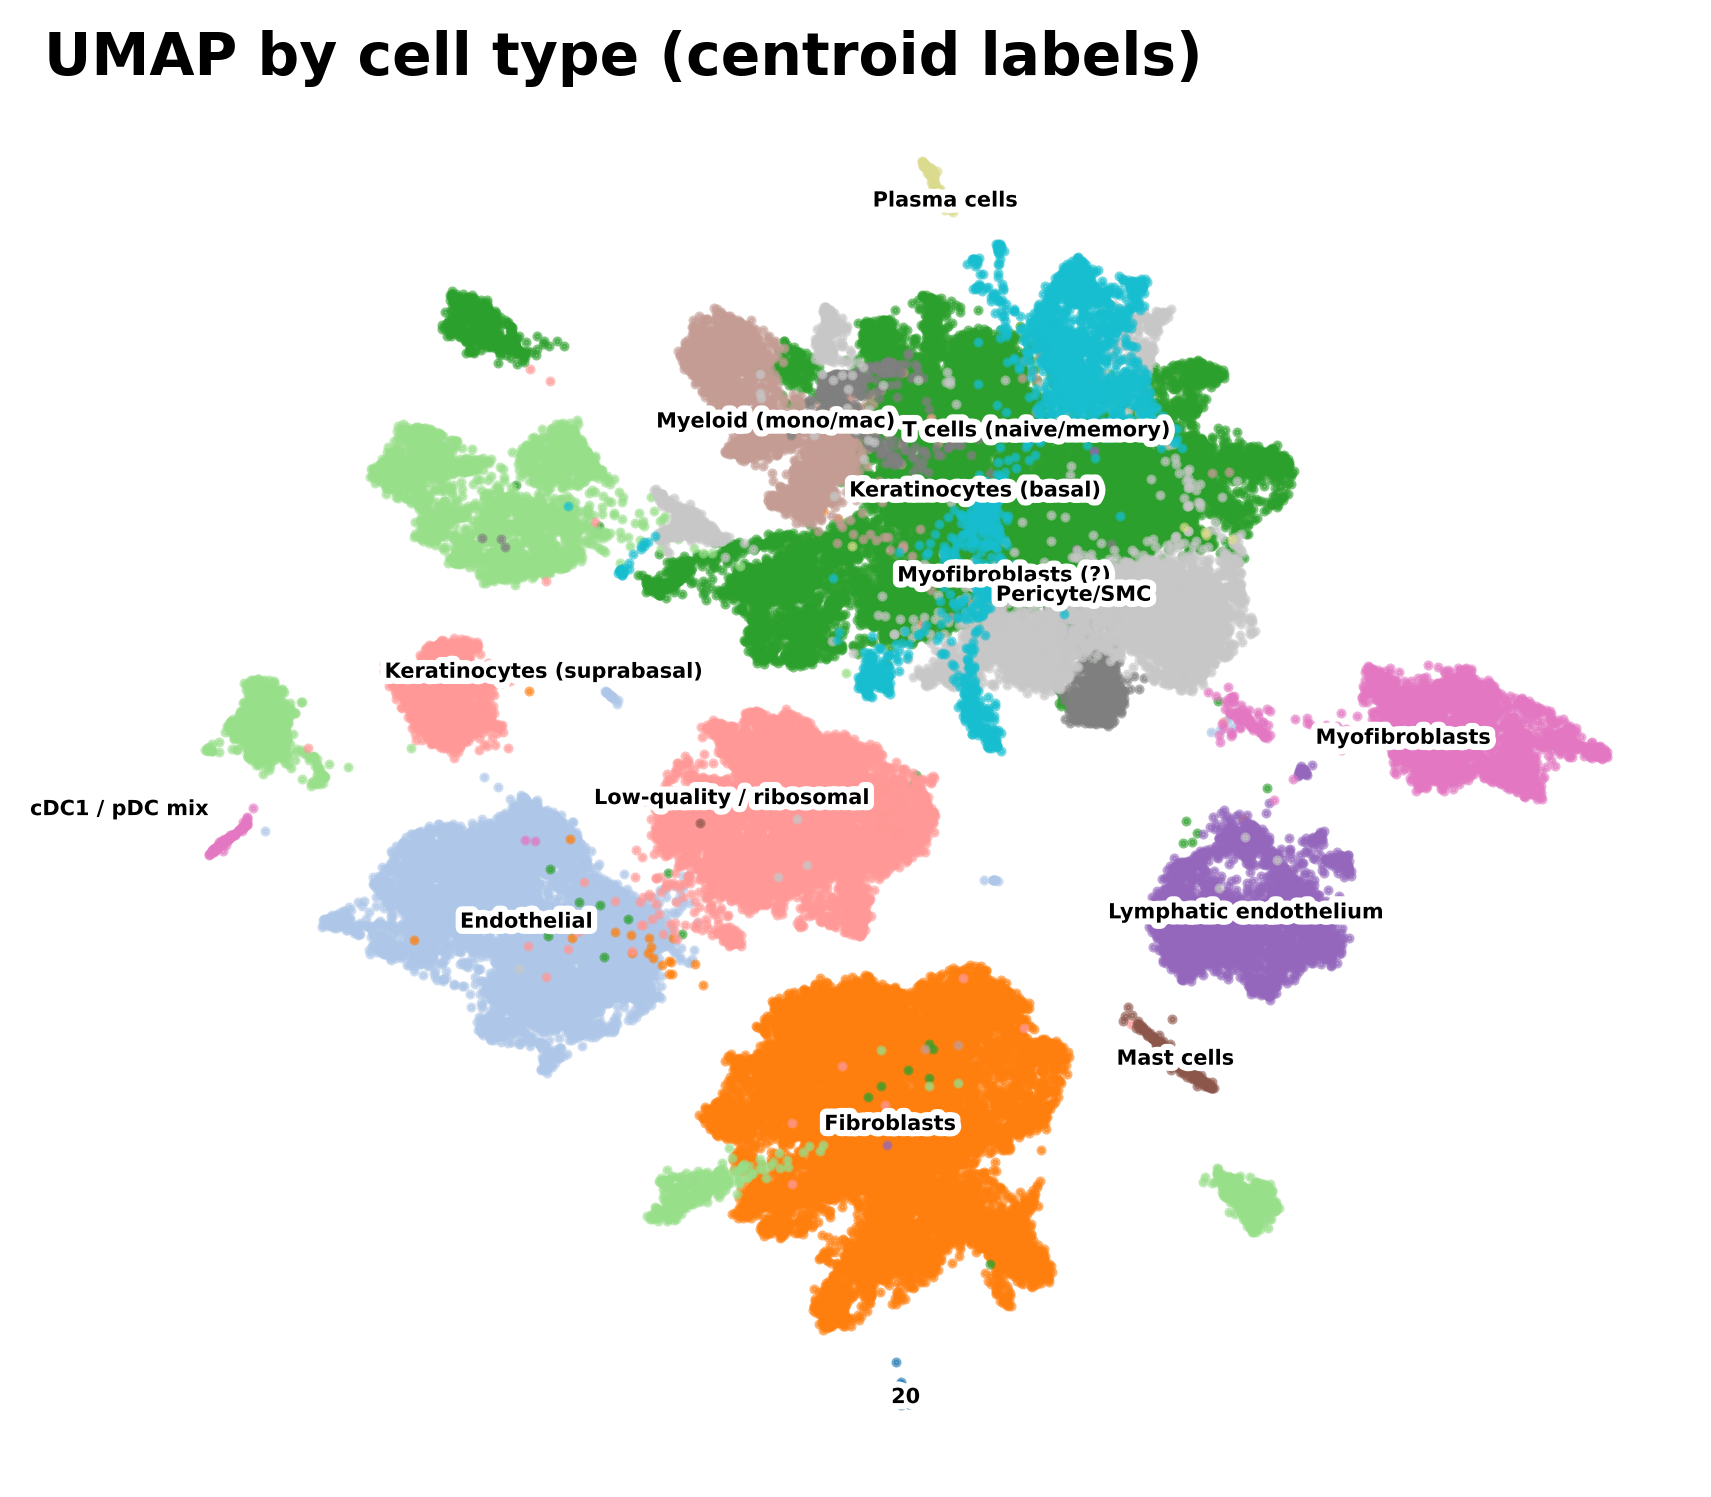

[saved] /home/glen/scleroderma-scvi/results/figures/umap_celltype_centroid_labels.png


In [5]:
# UMAP with text labels (cell-type names at centroids, not numbers)
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.patheffects as pe
from pathlib import Path

assert "X_umap" in adata.obsm, "UMAP coords missing: adata.obsm['X_umap']"

# 1) Pick a label column or build it from a mapping file
label_col = None
for c in ["cell_type", "celltype", "cell_types"]:
    if c in adata.obs.columns:
        label_col = c
        break

if label_col is None:
    # try to map leiden→cell_type from results/tables/leiden_to_celltype.csv
    map_csv = Path(ROOT / "results/tables/leiden_to_celltype.csv")
    if map_csv.exists() and "leiden" in adata.obs:
        m = pd.read_csv(map_csv)
        # be flexible on column names
        ct_col = next((c for c in ["cell_type","celltype","label","name"] if c in m.columns), None)
        assert ct_col is not None, f"No cell-type column in {map_csv}"
        # ensure leiden is string to match categorical codes safely
        m["leiden"] = m["leiden"].astype(str)
        adata.obs["leiden"] = adata.obs["leiden"].astype(str)
        adata.obs["cell_type"] = adata.obs["leiden"].map(dict(zip(m["leiden"], m[ct_col]))).fillna(adata.obs["leiden"])
        label_col = "cell_type"

if label_col is None:
    # last resort: still use leiden but you'll see numbers
    assert "leiden" in adata.obs, "No label column and no leiden found."
    label_col = "leiden"
    print("[warn] Using numeric 'leiden' labels; provide a cell_type column or mapping CSV to see names.")

# 2) Plot points + centroid labels
X = adata.obsm["X_umap"]
labels = adata.obs[label_col].astype(str).values
cats = pd.Categorical(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(cats.categories)))

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
for i, cat in enumerate(cats.categories):
    pts = X[cats.codes == i]
    if len(pts):
        ax.scatter(pts[:,0], pts[:,1], s=2, alpha=0.6, color=colors[i])

# centroid text labels with white stroke for legibility
for i, cat in enumerate(cats.categories):
    pts = X[cats.codes == i]
    if len(pts):
        cx, cy = pts[:,0].mean(), pts[:,1].mean()
        ax.text(cx, cy, cat, ha="center", va="center", fontsize=5, weight="bold",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")])

ax.set_xticks([]); ax.set_yticks([]); ax.set_frame_on(False)
ax.set_title("UMAP by cell type (centroid labels)", loc="left", fontweight="bold")

out = Path(ROOT / "results/figures/umap_celltype_centroid_labels.png")
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print("[saved]", out)


In [6]:
import numpy as np
import pandas as pd

primary  = "cell_type"
fallback = "leiden"

s = adata.obs[primary].astype(str)
is_numeric = s.str.fullmatch(r"\d+")

def majority_non_numeric(series: pd.Series) -> str | float:
    # keep only non-numeric-looking labels
    vals = series.astype(str)
    vals = vals[~vals.str.fullmatch(r"\d+")]
    if vals.empty:
        return np.nan
    return vals.value_counts().idxmax()

# leiden -> majority non-numeric cell_type (if any)
grp = (
    adata.obs.groupby(fallback, observed=True)[primary]
    .apply(majority_non_numeric)
)
mode_map = grp.dropna().to_dict()

# propose replacements for numeric-looking cell_type values
to_fill = adata.obs.loc[is_numeric, fallback].map(mode_map)

# apply only where we have a name
mask = is_numeric & to_fill.notna()
before = s[mask].copy()
s.loc[mask] = to_fill.loc[mask]

adata.obs[primary] = pd.Categorical(s)

print(f"Replaced {mask.sum()} numeric labels.",
      "\nExamples:",
      pd.DataFrame({"leiden": adata.obs.loc[mask, fallback],
                    "old": before,
                    "new": s.loc[mask]}).head(10))


Replaced 0 numeric labels. 
Examples: Empty DataFrame
Columns: [leiden, old, new]
Index: []


In [7]:
import scanpy as sc


adata_tmp = adata.copy()
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
sc.pp.log1p(adata_tmp)

sc.tl.rank_genes_groups(
    adata_tmp,
    groupby="leiden",
    groups=["20"],
    reference="rest",
    method="wilcoxon",
)
df20 = sc.get.rank_genes_groups_df(adata_tmp, group="20")  # <- no .query()
df20.head(15)


/home/glen/miniforge3/envs/ssc-scvi/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


,names,scores,logfoldchanges,pvals,pvals_adj
0,ENSG00000180879,12.372592,57.995453,3.677610e-35,4.248836e-31
1,ENSG00000211896,12.370137,858.557861,3.791742e-35,4.248836e-31
2,ENSG00000051523,12.276422,53.518841,1.212437e-34,9.057310e-31
3,ENSG00000051108,12.180028,122.115883,3.971441e-34,2.225099e-30
4,ENSG00000170476,12.134824,30.215925,6.905822e-34,3.095327e-30
5,ENSG00000100219,12.072692,20.459171,1.472386e-33,5.499606e-30
6,ENSG00000166562,11.728352,15.628287,9.121776e-32,2.920402e-28
7,ENSG00000211897,11.668858,850.077332,1.838751e-31,5.151032e-28
8,ENSG00000211893,11.203226,198.579803,3.931517e-29,9.744944e-26
9,ENSG00000099958,11.190899,19.241251,4.518282e-29,9.744944e-26


In [8]:
import scanpy as sc

# Option 1: use an existing normalized/log layer if present
norm_layer = None
for cand in ["scvi_normalized", "log1p", "lognorm"]:
    if cand in (adata.layers.keys() if hasattr(adata, "layers") else []):
        norm_layer = cand
        break

if norm_layer:
    sc.tl.rank_genes_groups(
        adata, groupby="leiden", groups=["20"], reference="rest",
        method="wilcoxon", layer=norm_layer
    )
    df20 = sc.get.rank_genes_groups_df(adata, group="20")
else:
    # Option 2: make a temp normalized/log1p copy
    adata_tmp = adata.copy()
    sc.pp.normalize_total(adata_tmp, target_sum=1e4)
    sc.pp.log1p(adata_tmp)
    sc.tl.rank_genes_groups(
        adata_tmp, groupby="leiden", groups=["20"],
        reference="rest", method="wilcoxon"
    )
    df20 = sc.get.rank_genes_groups_df(adata_tmp, group="20")

df20.head(15)


/home/glen/miniforge3/envs/ssc-scvi/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


,names,scores,logfoldchanges,pvals,pvals_adj
0,ENSG00000180879,12.372592,57.995453,3.677610e-35,4.248836e-31
1,ENSG00000211896,12.370137,858.557861,3.791742e-35,4.248836e-31
2,ENSG00000051523,12.276422,53.518841,1.212437e-34,9.057310e-31
3,ENSG00000051108,12.180028,122.115883,3.971441e-34,2.225099e-30
4,ENSG00000170476,12.134824,30.215925,6.905822e-34,3.095327e-30
5,ENSG00000100219,12.072692,20.459171,1.472386e-33,5.499606e-30
6,ENSG00000166562,11.728352,15.628287,9.121776e-32,2.920402e-28
7,ENSG00000211897,11.668858,850.077332,1.838751e-31,5.151032e-28
8,ENSG00000211893,11.203226,198.579803,3.931517e-29,9.744944e-26
9,ENSG00000099958,11.190899,19.241251,4.518282e-29,9.744944e-26


In [9]:
import pandas as pd

def ensembl_to_symbol(adata):
    sources = []
    if adata.raw is not None:
        sources.append(adata.raw.var)
    sources.append(adata.var)

    for V in sources:
        # Prefer a SYMBOL-like column
        for col in ["SYMBOL","gene_symbol","gene_name","symbol","Gene","name","feature_name"]:
            if col in V.columns:
                return V[col].astype(str).to_dict()
    # Fallback: if no symbol column exists, map to var_names themselves
    if adata.raw is not None:
        return pd.Series(adata.raw.var_names, index=adata.raw.var_names).to_dict()
    return pd.Series(adata.var_names, index=adata.var_names).to_dict()

sym_map = ensembl_to_symbol(adata)
df20 = df20.assign(symbol=df20["names"].map(sym_map))
df20[["symbol","scores","logfoldchanges","pvals_adj"]].head(20)


,symbol,scores,logfoldchanges,pvals_adj
0,SSR4,12.372592,57.995453,4.248836e-31
1,IGHG1,12.370137,858.557861,4.248836e-31
2,CYBA,12.276422,53.518841,9.057310e-31
3,HERPUD1,12.180028,122.115883,2.225099e-30
4,MZB1,12.134824,30.215925,3.095327e-30
5,XBP1,12.072692,20.459171,5.499606e-30
6,SEC11C,11.728352,15.628287,2.920402e-28
7,IGHG3,11.668858,850.077332,5.151032e-28
8,IGHG2,11.203226,198.579803,9.744944e-26
9,DERL3,11.190899,19.241251,9.744944e-26


In [10]:
primary, fallback = "cell_type", "leiden"

# assign human-readable label to all cells with leiden == "20"
label = "Plasma cells"
s = adata.obs[primary].astype(str)
s.loc[adata.obs[fallback].astype(str) == "20"] = label
adata.obs[primary] = pd.Categorical(s)

# (optional) make it the first time you export figures so UMAP shows the new label


In [11]:
marker_sets = {
    "Fibroblast": {"COL1A1","COL1A2","DCN","LUM","TAGLN","ACTA2","PDGFRA"},
    "Keratinocyte (basal)": {"KRT5","KRT14","ITGA6","KRT15","COL17A1"},
    "Keratinocyte (diff.)": {"KRT1","KRT10","IVL","SPRR1B"},
    "Endothelial": {"PECAM1","VWF","KDR","FLT1"},
    "Pericyte/SMC": {"RGS5","PDGFRB","ACTA2","TAGLN"},
    "Myeloid": {"LYZ","S100A8","S100A9","LST1","MNDA"},
    "T cell": {"CD3D","CD3E","TRAC","CCR7"},
    "B cell": {"MS4A1","CD79A","CD79B","BANK1"},
    "Plasma cell": {"MZB1","XBP1","JCHAIN"},
}

top_syms = [s for s in df20["symbol"].dropna().astype(str).tolist()[:100]]
hits = {ct: len(set(top_syms) & genes) for ct, genes in marker_sets.items()}
suggest = max(hits, key=hits.get)
hits, suggest


({'Fibroblast': 0,
  'Keratinocyte (basal)': 0,
  'Keratinocyte (diff.)': 0,
  'Endothelial': 0,
  'Pericyte/SMC': 0,
  'Myeloid': 0,
  'T cell': 0,
  'B cell': 1,
  'Plasma cell': 3},
 'Plasma cell')

## Figure 3 (Cleaned): UMAP with centroid labels + Fibro/Keratinocyte dotplots

_This section replaces the earlier Fig 3 logic with deterministic colors, stable labels, and robust SYMBOL→var mapping for dotplots._

[saved] /home/glen/scleroderma-scvi/results/figures/fig_celltype.png


[saved] /home/glen/scleroderma-scvi/results/figures/fig_celltype.pdf


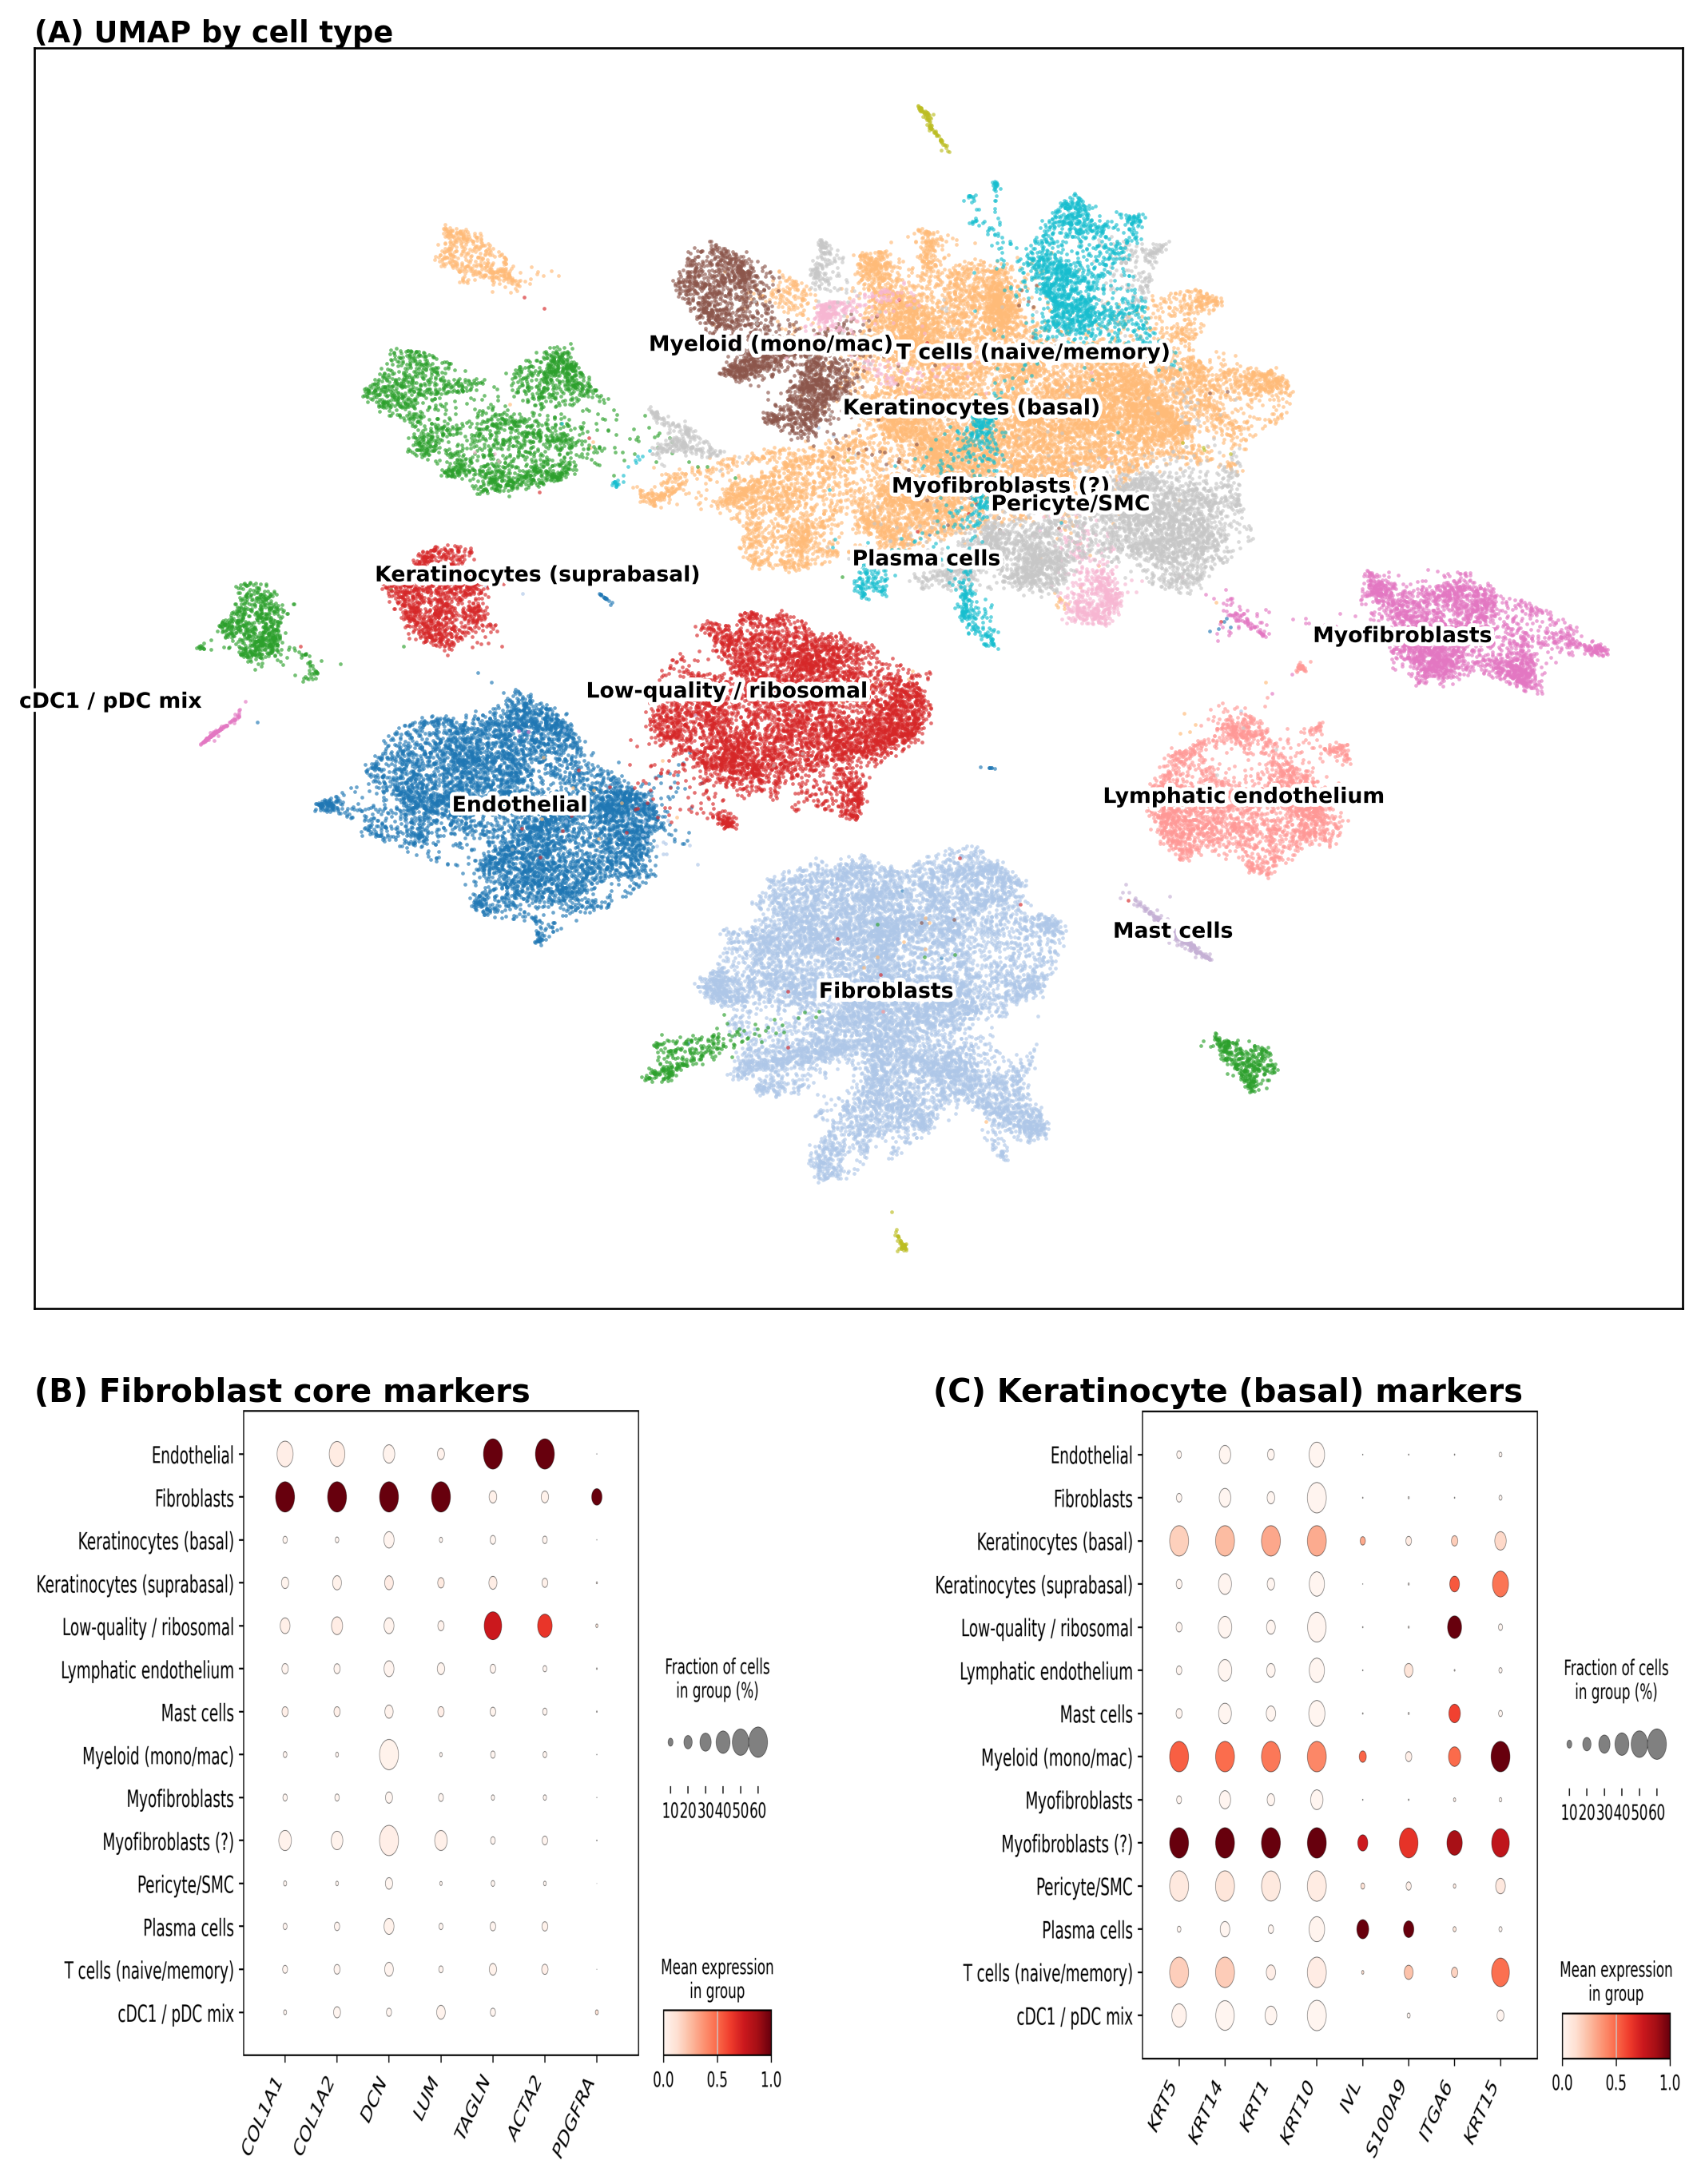

In [12]:
# === Figure 3 (finalized): UMAP + Fibro/Keratinocyte dotplots ===
# Compact layout for manuscripts/Word; readable labels; deterministic colors
# Outputs: results/figures/fig_celltype.{png,pdf}

import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl
import matplotlib.patheffects as pe
from pathlib import Path
import os, math

# ------------------------------ PARAMS ------------------------------
# Overall export
#COMPOSITE_SIZE   = (9.0, 10.0)   # inches (W,H). ~1-column in Word; increase to 10–11 if needed
COMPOSITE_SIZE   = (9.0, 12.0)   # inches (W,H). ~1-column in Word; increase to 10–11 if needed
EXPORT_DPI       = 300

# UMAP styling
UMAP_POINT_SIZE  = 2.0
UMAP_ALPHA       = 0.65
#UMAP_LABEL_SIZE  = 11
UMAP_LABEL_SIZE  = 8

# Grid layout & spacing (tighten vertical whitespace)
#GRID_HEIGHTS     = [1.0, 1.2]    # [top row, bottom row]
GRID_HEIGHTS     = [2.0, 1.2]    # [top row, bottom row]
GRID_WSPACE      = 0.20
#GRID_HSPACE      = 0.02
GRID_HSPACE      = 0.1
TITLE_SIZE_A     = 11
TITLE_SIZE_BC    = 12

# Dotplot generation (saved as PNGs and composited)
DOT_FIGSIZE      = (7.0, 5.5)    # per-dotplot inches
DOT_DPI          = 350
DOT_FONT_BASE    = 12            # base rcParam while building dotplots
DOT_TICK_FONTS   = 11            # x/y tick font size inside dotplots
DOT_XROT         = 55            # rotate x-labels to reduce clutter
DOT_PAD_INCH     = 0.02          # trim surrounding whitespace when saving
DOT_MAX          = 0.6           # scanpy dot_max
DOT_STD_SCALE    = "var"         # scanpy standard_scale

# Marker sets
FIBRO_MARKERS    = ["COL1A1","COL1A2","DCN","LUM","TAGLN","ACTA2","PDGFRA"]
KERATIN_MARKERS  = ["KRT5","KRT14","KRT1","KRT10","IVL","S100A9","ITGA6","KRT15"]

# Output dir
ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT  = ROOT / "results/figures"; OUT.mkdir(parents=True, exist_ok=True)
# -------------------------------------------------------------------

assert "X_umap" in adata.obsm, "UMAP coords missing in adata.obsm['X_umap']"
cand_groups = ["cell_type","celltype","cell_types","leiden","cluster","cluster_id"]
primary = next((c for c in cand_groups if c in adata.obs.columns), None)
assert primary, f"No grouping column found (tried {cand_groups})"

# ---------- helpers ----------
SYM_COLS = ["SYMBOL","gene_symbol","gene_symbols","gene_name","symbol","Gene","name","feature_name"]

def _symbol_table(adata):
    """Return (table, using_raw, symbol_col or None). Table has columns SYMBOL_U,var_name."""
    if adata.raw is not None:
        V = adata.raw.var
        for col in SYM_COLS:
            if col in V.columns:
                tab = pd.DataFrame({"SYMBOL_U": V[col].astype(str).str.upper(),
                                    "var_name": adata.raw.var_names}).drop_duplicates("SYMBOL_U")
                return tab, True, col
        tab = pd.DataFrame({"SYMBOL_U": pd.Index(adata.raw.var_names).astype(str).str.upper(),
                            "var_name": adata.raw.var_names}).drop_duplicates("SYMBOL_U")
        return tab, True, None
    V = adata.var
    for col in SYM_COLS:
        if col in V.columns:
            tab = pd.DataFrame({"SYMBOL_U": V[col].astype(str).str.upper(),
                                "var_name": adata.var_names}).drop_duplicates("SYMBOL_U")
            return tab, False, col
    tab = pd.DataFrame({"SYMBOL_U": pd.Index(adata.var_names).astype(str).str.upper(),
                        "var_name": adata.var_names}).drop_duplicates("SYMBOL_U")
    return tab, False, None

def map_symbols_to_varnames(adata, symbols):
    """Return (var_names, display_symbols, missing_symbols, using_raw_flag)."""
    tab, using_raw, _ = _symbol_table(adata)
    df = pd.DataFrame({"symbol": symbols, "SYMBOL_U": [s.upper() for s in symbols]})
    df = df.merge(tab, on="SYMBOL_U", how="left")
    ok = df["var_name"].notna()
    varnames = df.loc[ok, "var_name"].astype(str).tolist()
    display  = df.loc[ok, "symbol"].tolist()
    missing  = df.loc[~ok, "symbol"].tolist()
    return varnames, display, missing, using_raw

def dotplot_symbols(adata, symbols, groupby, tmp_png: Path):
    """Build Scanpy dotplot from SYMBOL list, save to PNG, relabel x-axis with symbols."""
    import scanpy as sc
    varnames, display, missing, use_raw = map_symbols_to_varnames(adata, symbols)
    if missing:
        print("[warn] Missing symbols (from", "raw" if use_raw else "var", "):", missing)
    if not varnames:
        return None

    old_rc = mpl.rcParams["font.size"]
    mpl.rcParams.update({"font.size": DOT_FONT_BASE})
    try:
        dp = sc.pl.dotplot(
            adata,
            var_names=varnames,
            groupby=groupby,
            use_raw=use_raw,
            standard_scale=DOT_STD_SCALE,
            dot_max=DOT_MAX,
            expression_cutoff=0.0,
            figsize=DOT_FIGSIZE,
            return_fig=True,
            show=False,
        )
        # materialize figure across versions
        fig = None
        try:
            _ = getattr(dp, "make_figure", lambda: None)()
            fig = getattr(dp, "fig", None)
        except Exception:
            pass
        if fig is None:
            fig = plt.gcf()
        if not getattr(fig, "axes", []):
            plt.close(fig); return None

        # relabel x with SYMBOLs and enlarge tick fonts
        def relabel(ax):
            try:
                ax.set_xticklabels(display, rotation=DOT_XROT, ha="right", fontsize=DOT_TICK_FONTS)
            except Exception:
                pass
            ax.tick_params(axis="y", labelsize=DOT_TICK_FONTS)

        if hasattr(dp, "ax_dict") and "mainplot_ax" in dp.ax_dict:
            relabel(dp.ax_dict["mainplot_ax"])
        else:
            for ax in fig.axes:
                if len(ax.get_xticklabels()) == len(display):
                    relabel(ax)

        fig.savefig(tmp_png, dpi=DOT_DPI, bbox_inches="tight", pad_inches=DOT_PAD_INCH)
        plt.close(fig)
        return tmp_png if tmp_png.exists() else None
    finally:
        mpl.rcParams.update({"font.size": old_rc})

def draw_umap_stable(adata, groupby, ax):
    X = adata.obsm["X_umap"]
    g = adata.obs[groupby].astype(str)
    cats = sorted(pd.unique(g))
    g = pd.Categorical(g, categories=cats, ordered=True)

    cmap = mpl.colormaps.get_cmap("tab20")
    colors = cmap(np.linspace(0, 1, len(cats)))
    color_map = {cat: colors[i] for i, cat in enumerate(cats)}

    for i, cat in enumerate(cats):
        idx = (g.codes == i)
        pts = X[idx]
        if pts.size == 0: 
            continue
        ax.scatter(pts[:,0], pts[:,1], s=UMAP_POINT_SIZE, alpha=UMAP_ALPHA,
                   color=color_map[cat], linewidths=0)
    for i, cat in enumerate(cats):
        idx = (g.codes == i); pts = X[idx]
        if pts.size == 0: 
            continue
        cx, cy = float(np.mean(pts[:,0])), float(np.mean(pts[:,1]))
        ax.text(cx, cy, cat, fontsize=UMAP_LABEL_SIZE, weight="bold",
                ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(""); ax.set_ylabel("")

# ---------- build dotplots to temp PNGs ----------
tmpB = OUT / "_tmp_fig3B.png"
tmpC = OUT / "_tmp_fig3C.png"
pngB = dotplot_symbols(adata, FIBRO_MARKERS,  groupby=primary, tmp_png=tmpB)
pngC = dotplot_symbols(adata, KERATIN_MARKERS, groupby=primary, tmp_png=tmpC)

# ---------- assemble final 3-panel figure ----------
fig = plt.figure(figsize=COMPOSITE_SIZE)
gs  = fig.add_gridspec(2, 2, height_ratios=GRID_HEIGHTS, wspace=GRID_WSPACE, hspace=GRID_HSPACE)

# (A) UMAP
axA = fig.add_subplot(gs[0, :])
draw_umap_stable(adata, groupby=primary, ax=axA)
axA.set_title("(A) UMAP by cell type", loc="left", fontweight="bold", fontsize=TITLE_SIZE_A, pad=2)

# (B)
axB = fig.add_subplot(gs[1, 0])
if pngB and Path(pngB).exists():
    axB.imshow(plt.imread(pngB), aspect="auto")
    axB.axis("off")
else:
    axB.axis("off"); axB.text(0.5, 0.5, "(B) no markers resolved", ha="center", va="center")
axB.set_title("(B) Fibroblast core markers", loc="left", fontweight="bold", fontsize=TITLE_SIZE_BC, pad=2)

# (C)
axC = fig.add_subplot(gs[1, 1])
if pngC and Path(pngC).exists():
    axC.imshow(plt.imread(pngC), aspect="auto")
    axC.axis("off")
else:
    axC.axis("off"); axC.text(0.5, 0.5, "(C) no markers resolved", ha="center", va="center")
axC.set_title("(C) Keratinocyte (basal) markers", loc="left", fontweight="bold", fontsize=TITLE_SIZE_BC, pad=2)

plt.subplots_adjust(left=0.04, right=0.995, top=0.98, bottom=0.06)

for ext in ("png","pdf"):
    out = OUT / f"fig_celltype.{ext}"
    fig.savefig(out, dpi=EXPORT_DPI, bbox_inches="tight")
    print(f"[saved] {out}")

plt.show()

# cleanup
for p in [tmpB, tmpC]:
    try: os.remove(p)
    except OSError: pass


[saved] /home/glen/scleroderma-scvi/results/figures/fig5_dose_time_examples.png
[saved] /home/glen/scleroderma-scvi/results/figures/fig5_dose_time_examples.pdf


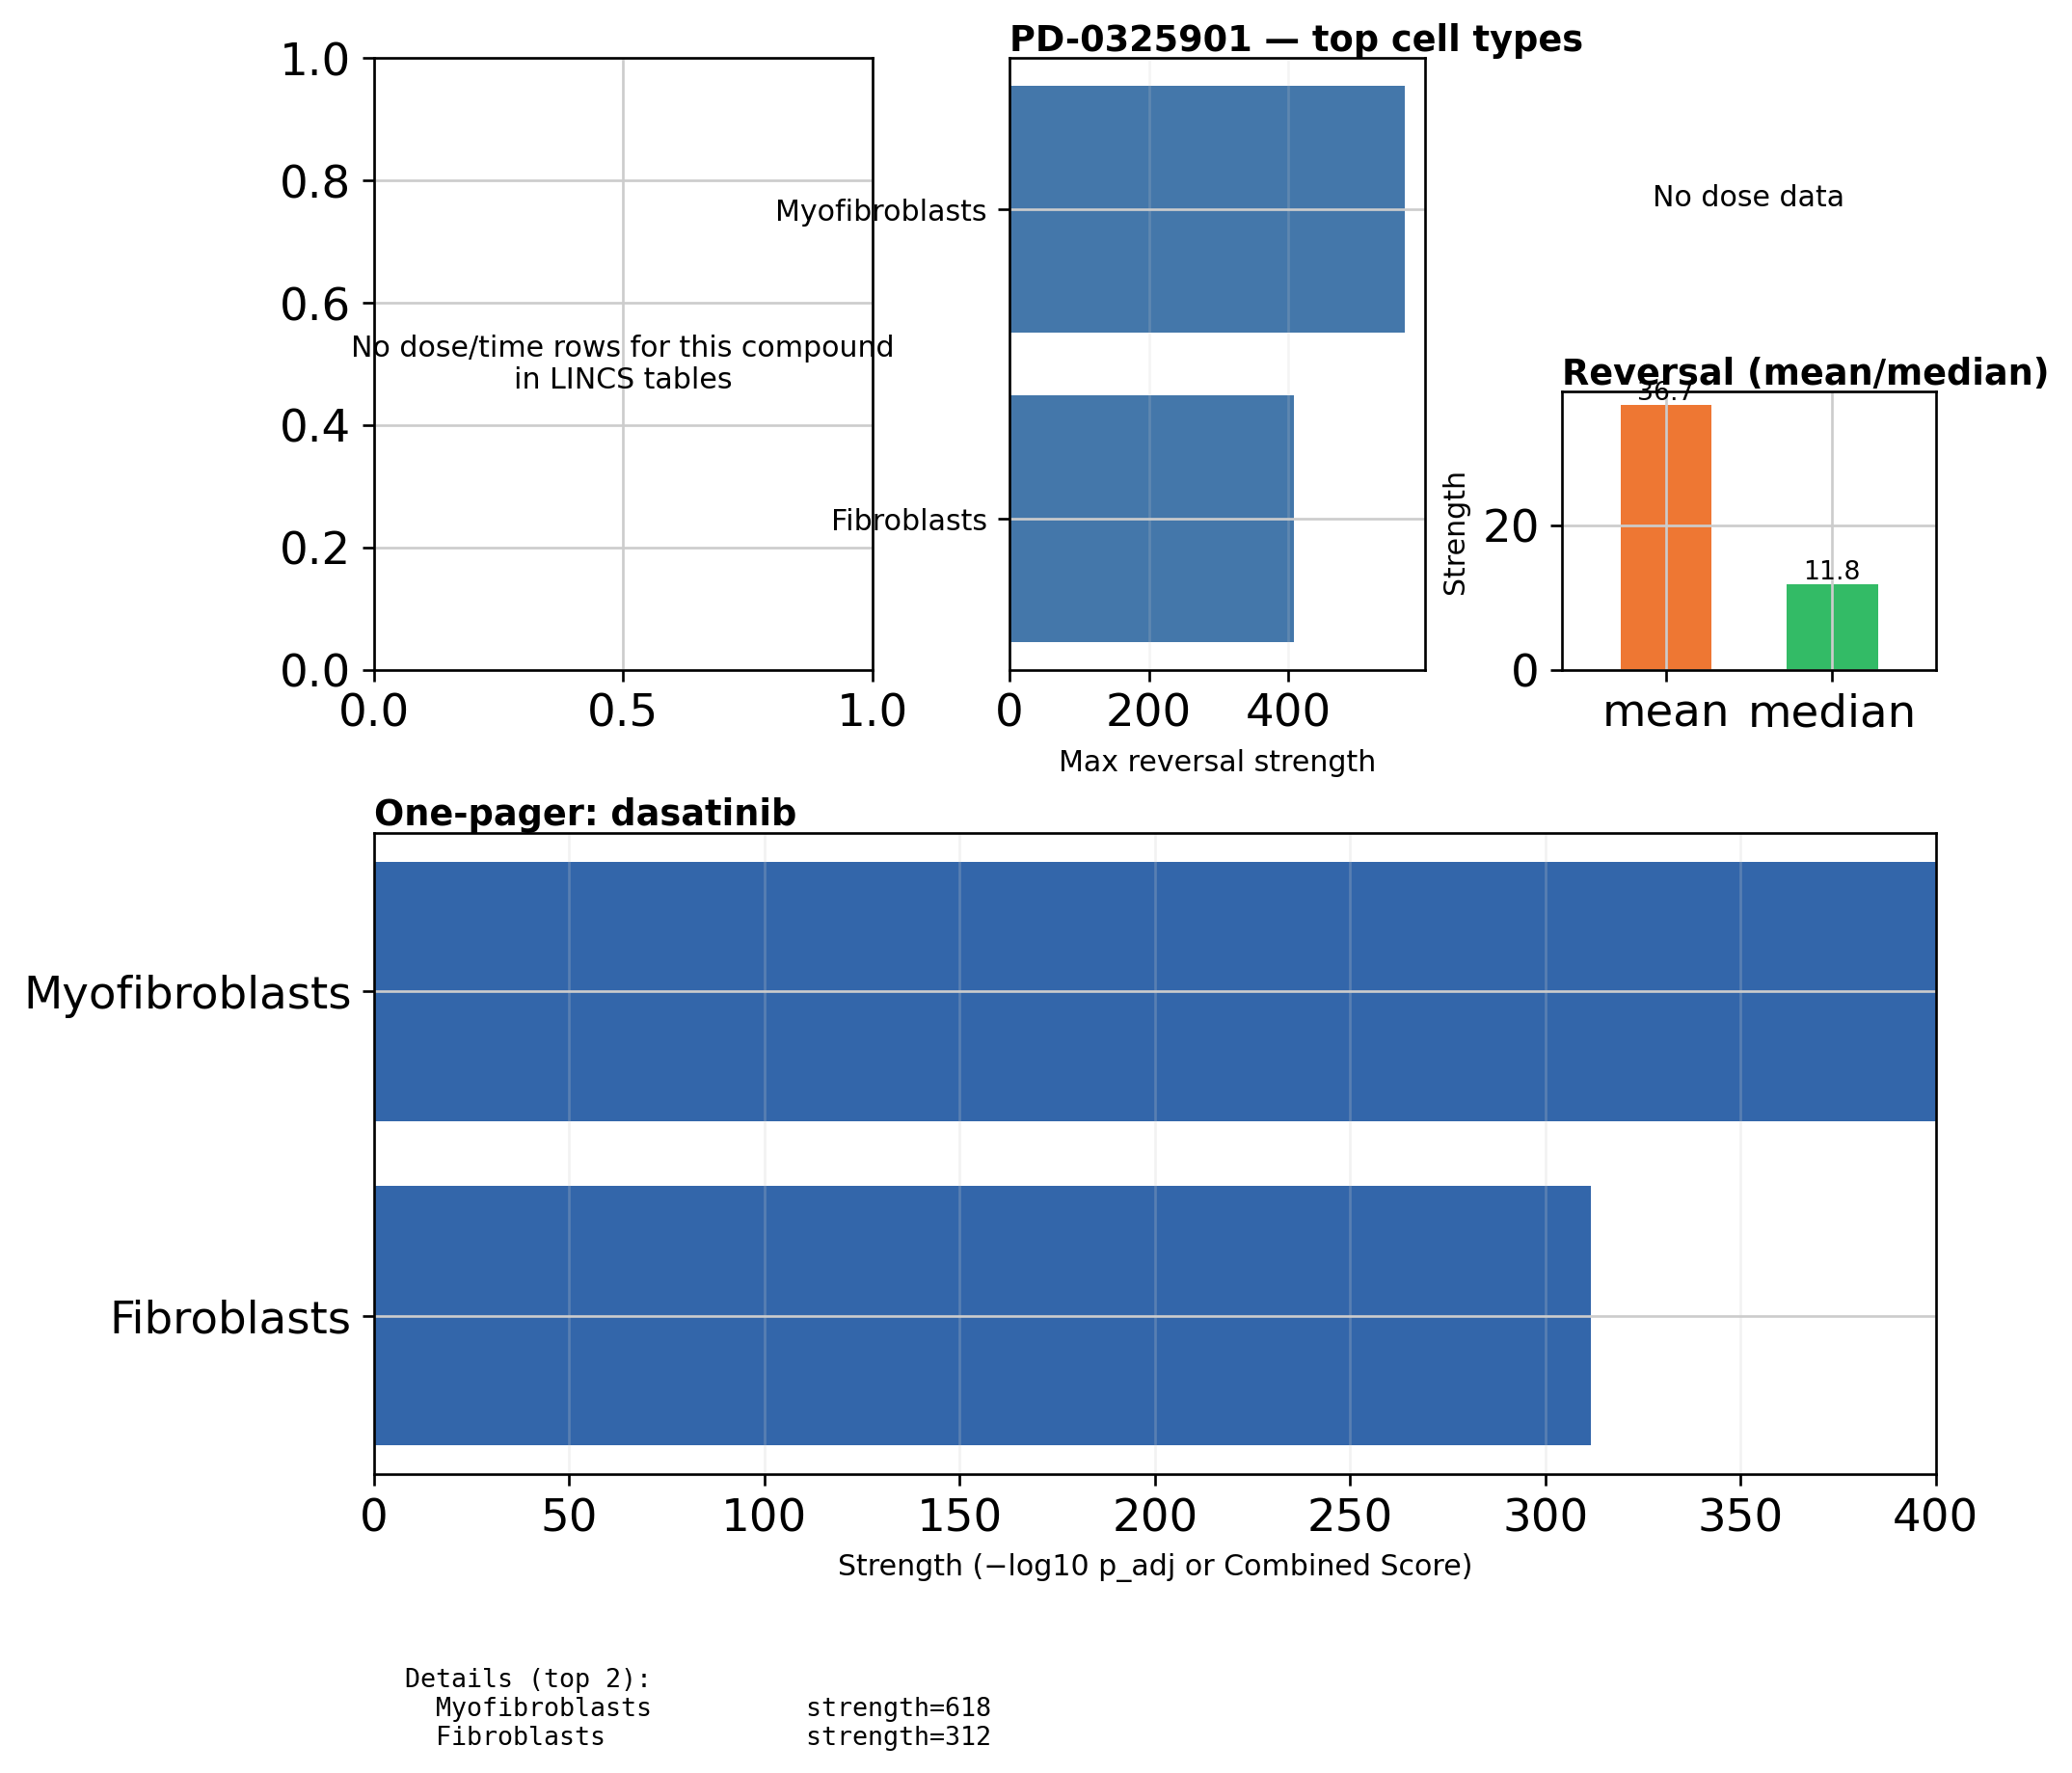

In [13]:
# === Figure 5 (polished & parameterized): Dose/time consistency & examples ===
# Finds drug_hits_*.csv under ROOT and CWD, parses dose/time from Term, and
# saves: results/figures/fig5_dose_time_examples.{png,pdf}

import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl, re, glob
from pathlib import Path

# ----------------------------- PARAMETERS -------------------------------------
COMPOUND_A = "PD-0325901"
COMPOUND_B = "dasatinib"

# Project root (set earlier in notebook if you have one)
ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)

# Where to search for CSVs (recursive)
SEARCH_ROOTS = [
    ROOT, ROOT/"results"/"tables", ROOT/"tables",
    Path.cwd(), Path.cwd()/"results"/"tables", Path.cwd()/"tables",
]

# Layout & fonts (Word-friendly)
FIG_SIZE   = (7.5, 7.2)
DPI        = 300
FONTS      = {"base":10, "titleA":11, "titleB":11, "ticks":9, "small":8}

# Grid spacing/ratios (tighter by default)
TOP_HEIGHT_RATIOS = [1.0, 1.05]   # [top row, bottom row]
TOP_WIDTH_RATIOS  = [1.2, 1.0, 0.9]
WSPACE            = 0.32
HSPACE            = 0.26

# Bars & details
TOP_N_GROUPS_A = 6
TOP_N_GROUPS_B = 6
DETAILS_N      = 10

# Behavior toggles
USE_ONLY_LINCS_FOR_PANEL_B      = True   # Panel B uses only LINCS rows if available
ALWAYS_ADD_COLLAPSED_A1         = True   # Always draw collapsed dose curve for A1 (median across doses)
SHOW_COLLAPSED_IF_NO_TRACES_A1  = True   # Also show collapsed curve if traces are unavailable
ANNOTATE_A4_BARS                = True   # Numeric labels on mean/median bars

# Axis caps
PANEL_B_XMAX = 400              # None for auto; number to cap x-axis in Panel B

# Colors/markers
COLORS  = mpl.colormaps.get_cmap("tab10")
MARKERS = ["o","s","D","^","v","P","X","*"]

# Output
OUT = ROOT / "results" / "figures"; OUT.mkdir(parents=True, exist_ok=True)
OUT_STEM = "fig5_dose_time_examples"
# -----------------------------------------------------------------------------

# ------------------------ Discover & read drug_hits CSVs ----------------------
TERM_CANDS = ["Term","term","Term Name","Term_Name","Name","name","ID","id"]

def _find_hits_files():
    files = []
    for base in SEARCH_ROOTS:
        if Path(base).exists():
            files += glob.glob(str(Path(base) / "**" / "drug_hits_*.csv"), recursive=True)
    return sorted(set(files))

def _read_hits_csv(path: str) -> pd.DataFrame | None:
    try:
        df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig", on_bad_lines="skip")
    except TypeError:
        df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except Exception:
        return None
    df.columns = [c.strip() for c in df.columns]
    col = next((c for c in TERM_CANDS if c in df.columns), None)
    if not col: return None
    if col != "Term": df = df.rename(columns={col:"Term"})
    stem = Path(path).stem
    group = stem.replace("drug_hits_","")
    for stop in ["_UP","_DOWN","_combined"]:
        if stop in group: group = group.split(stop)[0]; break
    src = next((t for t in [
        "LINCS_L1000_Chem_Pert_down","LINCS_L1000_Chem_Pert_up",
        "Drug_Perturbations_from_GEO_down","Drug_Perturbations_from_GEO_up",
        "ALL","combined"
    ] if t in stem), "unknown")
    df["__group"]  = group
    df["__source"] = src
    return df

# -------------------------- Parse term & strength -----------------------------
L1000_LINES = {
    "A375","A549","HT29","HEPG2","HCC515","HA1E","HME1","MCF7","PC3","SKBR3",
    "MCF10A","HUVEC","HEK293","HEK293T","HT1080","U2OS"
}
STRENGTH_COLS = [
    "Adjusted P-value","Adjusted P-value ","Adjusted P value","Adjusted P-value (BH)",
    "Combined Score","combined_score","Combined score",
    "P-value","p-value","P value"
]

def _parse_term(term: str):
    t = str(term)
    m_dose = re.search(r"(\d+(?:\.\d+)?)\s*(?:uM|µM|um)\b", t, flags=re.I)
    dose = float(m_dose.group(1)) if m_dose else np.nan
    m_time = re.search(r"(\d{1,3})\s*(?:h|hr|hrs|hour|hours)\b", t, flags=re.I)
    time_h = float(m_time.group(1)) if m_time else np.nan
    toks = re.split(r"[^A-Za-z0-9]+", t)
    line = next((tok for tok in toks if tok.upper() in L1000_LINES), "")
    cand = [tok for tok in toks if re.search(r"[A-Za-z]", tok)]
    cand = sorted(cand, key=lambda s: (-len(s), s))
    guess = cand[0] if cand else ""
    return dose, time_h, line, guess

def _strength_from_row(r: pd.Series) -> float:
    for c in STRENGTH_COLS:
        if c in r and pd.notna(r[c]):
            v = r[c]
            if "Combined" in c or "combined" in c:
                try: return float(v)
                except Exception: continue
            try:
                p = float(v); return -np.log10(max(p, 1e-300))
            except Exception:
                continue
    return np.nan

# ------------------------------- Build table ----------------------------------
files = _find_hits_files()
if not files:
    raise FileNotFoundError("No drug_hits_*.csv files found under the search roots.")

rows = []
for f in files:
    df = _read_hits_csv(f)
    if df is None or df.empty: 
        continue
    for _, r in df.iterrows():
        dose, time_h, line, guess = _parse_term(r["Term"])
        rows.append({
            "term": r["Term"],
            "group": df["__group"].iat[0],
            "source": df["__source"].iat[0],
            "strength": _strength_from_row(r),
            "dose_uM": dose,
            "time_h": time_h,
            "cell_line": line,
            "compound_guess": guess,
        })
R = pd.DataFrame(rows)
R = R[pd.notna(R["strength"])]
if R.empty:
    raise ValueError("Parsed files, but none had usable strength columns (Adj P / Combined / P).")

def _match(df, name: str) -> pd.DataFrame:
    name_l = name.lower()
    m = df[df["term"].str.lower().str.contains(name_l, na=False)]
    if m.empty:
        m = df[df["compound_guess"].str.lower().str.contains(name_l, na=False)]
    return m.copy()

A_all = _match(R, COMPOUND_A)
B_all = _match(R, COMPOUND_B)
if A_all.empty or B_all.empty:
    miss = []
    if A_all.empty: miss.append(COMPOUND_A)
    if B_all.empty: miss.append(COMPOUND_B)
    raise ValueError("No matching rows for: " + ", ".join(miss))

# Prefer LINCS (dose/time) for A; copy to avoid SettingWithCopyWarning
A_lincs = A_all[A_all["source"].str.contains("LINCS", na=False)]
A_show = (A_lincs if not A_lincs.empty else A_all).copy()

# Optionally restrict Panel B to LINCS only (fallback to all if empty)
if USE_ONLY_LINCS_FOR_PANEL_B:
    B_lincs = B_all[B_all["source"].str.contains("LINCS", na=False)]
    if not B_lincs.empty:
        B_all = B_lincs.copy()

# ------------------------------- Figure ---------------------------------------
mpl.rcParams.update({"font.size": FONTS["base"]})
fig = plt.figure(figsize=FIG_SIZE)
outer = fig.add_gridspec(
    2, 3, height_ratios=TOP_HEIGHT_RATIOS, width_ratios=TOP_WIDTH_RATIOS,
    wspace=WSPACE, hspace=HSPACE
)

# A1 — dose/time traces (+ optional collapsed)
axA1 = fig.add_subplot(outer[0, 0])

def _trace_label(row):
    parts = []
    if isinstance(row.get("cell_line",""), str) and row["cell_line"]:
        parts.append(row["cell_line"])
    if not np.isnan(row.get("time_h", np.nan)):
        parts.append(f"{int(row['time_h'])}h")
    return " @ ".join(parts) if parts else "all"

A_show["_trace"] = A_show.apply(_trace_label, axis=1)
curves_drawn = False
for i, tr in enumerate(sorted(A_show["_trace"].unique())):
    sub = (A_show[A_show["_trace"]==tr]
           .dropna(subset=["dose_uM","strength"])
           .sort_values("dose_uM"))
    if sub.empty: 
        continue
    axA1.plot(sub["dose_uM"], sub["strength"],
              marker=MARKERS[i % len(MARKERS)], linewidth=1.2,
              color=COLORS(i % 10), label=tr, zorder=2)
    curves_drawn = True

def _plot_collapsed(ax):
    sub = (A_all.dropna(subset=["dose_uM","strength"])
                 .groupby("dose_uM", as_index=False)["strength"].median()
                 .sort_values("dose_uM"))
    if not sub.empty:
        ax.plot(sub["dose_uM"], sub["strength"], marker="o", linewidth=1.6,
                color="#666666", alpha=0.85, label="collapsed (median)", zorder=2)
        return True
    return False

#if ALWAYS_ADD_COLLAPSED_A1:
#    _plot_collapsed(axA1)
#elif (not curves_drawn) and SHOW_COLLAPSED_IF_NO_TRACES_A1 and A_all["dose_uM"].notna().any():
#    _plot_collapsed(axA1)
#
#axA1.set_xlabel("Dose (µM, as given)", fontsize=FONTS["ticks"])
#axA1.set_ylabel("Reversal strength\n(−log10 p_adj or Combined Score)", fontsize=FONTS["ticks"])
#axA1.grid(True, alpha=0.25, zorder=0)
#if (len(A_show["_trace"].unique()) <= 6) or ALWAYS_ADD_COLLAPSED_A1:
#    axA1.legend(fontsize=FONTS["ticks"]-1, ncol=1, loc="center left",
#                bbox_to_anchor=(1.02, 0.5), frameon=False)
#axA1.set_title(COMPOUND_A, loc="left", fontsize=FONTS["titleA"], fontweight="bold", pad=2)
#if (not curves_drawn) and (not A_all["dose_uM"].notna().any()):
#    axA1.text(0.5, 0.5, "No dose/time rows for this compound\nin LINCS tables",
#              ha="center", va="center", fontsize=FONTS["ticks"])
#    axA1.set_xlim(0, 1); axA1.set_ylim(0, 1)

# ---- collapsed fallback & legend (robust) ------------------------------------
plotted_collapsed = False
if ALWAYS_ADD_COLLAPSED_A1:
    plotted_collapsed = _plot_collapsed(axA1)
elif (not curves_drawn) and SHOW_COLLAPSED_IF_NO_TRACES_A1 and A_all["dose_uM"].notna().any():
    plotted_collapsed = _plot_collapsed(axA1)

# Legend only if something with a label exists
handles, labels = axA1.get_legend_handles_labels()
if labels:
    axA1.legend(handles, labels,
                fontsize=FONTS["ticks"]-1, ncol=1, loc="center left",
                bbox_to_anchor=(1.02, 0.5), frameon=False)

# Optional: show the “no dose/time rows” message only if nothing was drawn at all
if not (curves_drawn or plotted_collapsed) and not A_all["dose_uM"].notna().any():
    axA1.text(0.5, 0.5, "No dose/time rows for this compound\nin LINCS tables",
              ha="center", va="center", fontsize=FONTS["ticks"])
    axA1.set_xlim(0, 1); axA1.set_ylim(0, 1)




# A2 — top cell types for A
axA2 = fig.add_subplot(outer[0, 1])
topA = (A_all.groupby("group", as_index=False)["strength"]
          .max().sort_values("strength", ascending=False)
          .head(TOP_N_GROUPS_A))
axA2.barh(topA["group"], topA["strength"], color="#4477AA")
axA2.invert_yaxis()
axA2.set_xlabel("Max reversal strength", fontsize=FONTS["ticks"])
axA2.set_ylabel("")
axA2.tick_params(axis="y", labelsize=FONTS["ticks"])
axA2.grid(axis="x", alpha=0.2)
axA2.set_title(f"{COMPOUND_A} — top cell types", loc="left",
               fontsize=FONTS["titleA"], fontweight="bold", pad=2)

# A3 (dose window) + A4 (mean/median)
right = outer[0, 2].subgridspec(2, 1, hspace=0.20)

axA3 = fig.add_subplot(right[0, 0])
A_dose = A_show["dose_uM"].dropna()
if not A_dose.empty:
    dmin, dmed, dmax = float(A_dose.min()), float(A_dose.median()), float(A_dose.max())
    axA3.hlines(1, dmin, dmax, lw=8, color="#999999", alpha=0.6)
    axA3.vlines([dmin, dmed, dmax], 0.8, 1.2, colors=["#555","#C33","#555"], lw=[2,3,2])
    axA3.set_ylim(0.7, 1.3); axA3.set_yticks([])
    axA3.set_xlabel("Dose (µM):  min | median | max", fontsize=FONTS["ticks"])
    axA3.set_title("Dose window", fontsize=FONTS["titleA"], pad=2, loc="left", fontweight="bold")
else:
    axA3.axis("off")
    axA3.text(0.5, 0.5, "No dose data", ha="center", va="center", fontsize=FONTS["ticks"])

axA4 = fig.add_subplot(right[1, 0])
if A_show["strength"].notna().any():
    mean_rev = float(A_show["strength"].mean()); med_rev = float(A_show["strength"].median())
    xs = [0.30, 0.70]; vals = [mean_rev, med_rev]
    axA4.bar(xs, vals, width=0.22, color=["#EE7733","#33BB66"])
    axA4.set_xlim(0.05, 0.95)
    axA4.set_xticks(xs, labels=["mean","median"])
    axA4.set_ylabel("Strength", fontsize=FONTS["ticks"])
    axA4.set_title("Reversal (mean/median)", fontsize=FONTS["titleA"], pad=2, loc="left", fontweight="bold")
    if ANNOTATE_A4_BARS:
        for x, v in zip(xs, vals):
            axA4.text(x, v, f"{v:.1f}", ha="center", va="bottom", fontsize=FONTS["small"])
else:
    axA4.axis("off")
    axA4.text(0.5, 0.5, "No reversal stats", ha="center", va="center", fontsize=FONTS["ticks"])

# B — one-pager for COMPOUND_B
axB = fig.add_subplot(outer[1, :])
sigB = (B_all.groupby("group", as_index=False)["strength"]
          .max().sort_values("strength", ascending=False))
topB = sigB.head(TOP_N_GROUPS_B)
axB.barh(topB["group"], topB["strength"], color="#3366AA")
axB.invert_yaxis()
axB.set_xlabel("Strength (−log10 p_adj or Combined Score)", fontsize=FONTS["ticks"])
axB.set_ylabel("")
axB.grid(axis="x", alpha=0.25)
axB.set_title(f"One-pager: {COMPOUND_B}", loc="left",
              fontsize=FONTS["titleB"], fontweight="bold", pad=2)
if PANEL_B_XMAX is not None:
    axB.set_xlim(0, PANEL_B_XMAX)

# details text
txt = [f"Details (top {min(DETAILS_N, len(sigB))}):"]
for _, r in sigB.head(DETAILS_N).iterrows():
    txt.append(f"  {r['group']:<22}  strength={r['strength']:.3g}")
axB.text(0.02, -0.30, "\n".join(txt), transform=axB.transAxes,
         ha="left", va="top", fontsize=FONTS["small"], family="monospace")

plt.subplots_adjust(left=0.08, right=0.98, top=0.95, bottom=0.10)
for ext in ("png","pdf"):
    out = OUT / f"{OUT_STEM}.{ext}"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"[saved] {out}")
plt.show()


# Supplementary Table S1

In [14]:
# === Supplementary Table S1: Ensembl → HGNC symbol map =======================
# - Prefers 10x/GTF symbols from .raw.var (then .var)
# - Optional curated overrides if a CSV is present
# - Flags presence in HVG matrix (.var) vs .raw, and duplicated symbols in .raw
# - Saves: results/tables/supp_table_s1_gene_map.csv
# ============================================================================

from pathlib import Path
import pandas as pd, numpy as np, re

# ---------- paths / setup ----------
ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT_DIR = ROOT / "results" / "tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / "supp_table_s1_gene_map.csv"

# optional curated map (any of these if present: two columns "ensembl_id_stripped","gene_symbol")
CURATED_CANDIDATES = [
    ROOT / "tables" / "ensembl_to_symbol_curated.csv",
    ROOT / "results" / "tables" / "ensembl_to_symbol_curated.csv",
    ROOT / "data" / "processed" / "ensembl_to_symbol_curated.csv",
]

# candidate symbol columns we’ll accept from 10x/GTF metadata
SYM_COLS = ["SYMBOL","gene_symbol","gene_symbols","gene_name","symbol","Gene","name","feature_name"]

def _strip_ver(x: pd.Index | pd.Series) -> pd.Index:
    """Remove version suffix like '.12' from Ensembl IDs."""
    return pd.Index(pd.Series(x, dtype=str).str.replace(r"\.\d+$", "", regex=True))

def _detect_symbol_series(var: pd.DataFrame):
    """Return (symbol_series, source_column_name) or (empty, None)."""
    for col in SYM_COLS:
        if col in var.columns:
            s = var[col].astype(str)
            s = s.where(s.str.len() > 0)  # empty -> NaN
            return s, col
    return pd.Series(index=var.index, dtype=object), None

def _to_map(index_like, sym_series, prefer_non_missing=True):
    """Build {ensembl_stripped -> symbol} map from an index & symbol Series."""
    df = pd.DataFrame({
        "ensembl_id": pd.Index(index_like).astype(str),
        "ensembl_id_stripped": _strip_ver(index_like),
        "symbol": sym_series.reindex(index_like).astype("string")
    })
    if prefer_non_missing:
        df = df.dropna(subset=["symbol"])
    df = df.drop_duplicates(subset=["ensembl_id_stripped"], keep="first")
    return df.set_index("ensembl_id_stripped")["symbol"].to_dict()

# ---------- gather IDs ----------
ids_var = pd.Index(adata.var_names.astype(str))
ids_raw = pd.Index(adata.raw.var_names.astype(str)) if adata.raw is not None else pd.Index([])
base_var = _strip_ver(ids_var)
base_raw = _strip_ver(ids_raw)
all_base = pd.Index(sorted(set(base_var).union(set(base_raw))))

# ---------- build symbol sources (10x / GTF first) ----------
raw_sym, raw_col = _detect_symbol_series(adata.raw.var) if adata.raw is not None else (pd.Series(index=ids_raw, dtype=object), None)
var_sym, var_col = _detect_symbol_series(adata.var)

raw_map = _to_map(ids_raw, raw_sym) if len(ids_raw) else {}
var_map = _to_map(ids_var, var_sym)

# duplicated symbol flag computed on raw symbols (after stripping IDs)
dup_raw_flag = {}
if len(ids_raw) and raw_col is not None:
    raw_tab = pd.DataFrame({
        "sym": raw_sym.reindex(ids_raw).astype("string"),
        "base": base_raw
    }).dropna()
    dup_syms = raw_tab.groupby("sym", dropna=True)["base"].nunique()
    dup_set = set(dup_syms[dup_syms > 1].index.tolist())
    dup_raw_flag = {b: (raw_map.get(b) in dup_set) for b in base_raw}

# ---------- optional curated overrides ----------
curated_map = {}
curated_path = next((p for p in CURATED_CANDIDATES if p.exists()), None)
if curated_path is not None:
    cdf = pd.read_csv(curated_path)
    # accept common column names
    c1 = next((c for c in cdf.columns if str(c).lower().startswith("ensembl")), None)
    c2 = next((c for c in cdf.columns if "symbol" in str(c).lower()), None)
    if c1 and c2:
        curated_map = (
            cdf.rename(columns={c1:"ensembl_id_stripped", c2:"gene_symbol"})
               .dropna(subset=["ensembl_id_stripped","gene_symbol"])
               .drop_duplicates("ensembl_id_stripped")
               .set_index("ensembl_id_stripped")["gene_symbol"]
               .astype(str)
               .to_dict()
        )

# ---------- decide final symbol + source per Ensembl base ----------
rows = []
for ensg in all_base:
    sym = None
    source = None
    note = ""

    # priority: raw → var → curated
    if ensg in raw_map:
        sym = raw_map[ensg]
        source = "10x_features / GTF"
        if raw_col: note = f"from raw.{raw_col}"
    elif ensg in var_map:
        sym = var_map[ensg]
        source = "10x_features / GTF"
        if var_col: note = f"from var.{var_col}"
    elif ensg in curated_map:
        sym = curated_map[ensg]
        source = "curated map"
        note = "curated override"
    else:
        sym = pd.NA
        source = pd.NA
        note = "no symbol available"

    rows.append({
        "ensembl_id_stripped": ensg,
        "gene_symbol": sym,
        "source_map": source,
        "present_in_hvg": bool(ensg in set(base_var)),
        "present_in_raw": bool(ensg in set(base_raw)),
        "duplicated_symbol_in_raw": bool(dup_raw_flag.get(ensg, False)),
        "notes": note,
    })

S1 = pd.DataFrame(rows).sort_values(["present_in_hvg","present_in_raw","gene_symbol","ensembl_id_stripped"],
                                    ascending=[False, False, True, True])

# write & preview
S1.to_csv(OUT_CSV, index=False)
print(f"[✓] Wrote {OUT_CSV}  ({len(S1):,} rows)")
display(S1.head(10))


[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s1_gene_map.csv  (22,411 rows)


,ensembl_id_stripped,gene_symbol,source_map,present_in_hvg,present_in_raw,duplicated_symbol_in_raw,notes
12653,ENSG00000175899,A2M,10x_features / GTF,True,True,False,from raw.gene_symbol
10925,ENSG00000166535,A2ML1,10x_features / GTF,True,True,False,from raw.gene_symbol
1473,ENSG00000081760,AACS,10x_features / GTF,True,True,False,from raw.gene_symbol
4099,ENSG00000114771,AADAC,10x_features / GTF,True,True,False,from raw.gene_symbol
15173,ENSG00000197953,AADACL2,10x_features / GTF,True,True,False,from raw.gene_symbol
15770,ENSG00000205002,AARD,10x_features / GTF,True,True,False,from raw.gene_symbol
16216,ENSG00000215458,AATBC,10x_features / GTF,True,True,False,from raw.gene_symbol
13384,ENSG00000181409,AATK,10x_features / GTF,True,True,False,from raw.gene_symbol
7970,ENSG00000144452,ABCA12,10x_features / GTF,True,True,False,from raw.gene_symbol
15345,ENSG00000198691,ABCA4,10x_features / GTF,True,True,False,from raw.gene_symbol


In [15]:
# Make Supplementary Table S1 deliverables: full CSV/XLSX + small RTF/TSV excerpt
from pathlib import Path
import pandas as pd, hashlib

ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT = ROOT / "results" / "tables"
OUT.mkdir(parents=True, exist_ok=True)

# Load S1 from memory or disk
if "S1" in globals() and isinstance(S1, pd.DataFrame):
    df = S1.copy()
else:
    df = pd.read_csv(OUT / "supp_table_s1_gene_map.csv")

# Reorder columns exactly as spec
cols = ["ensembl_id_stripped","gene_symbol","source_map",
        "present_in_hvg","present_in_raw","duplicated_symbol_in_raw","notes"]
df = df[cols]

# --- Full files ---
full_csv  = OUT / "supp_table_s1_gene_map.csv"   # overwrite to ensure consistent order
full_xlsx = OUT / "supp_table_s1_gene_map.xlsx"
df.to_csv(full_csv, index=False)
try:
    df.to_excel(full_xlsx, index=False)
    print("[✓] wrote", full_xlsx)
except Exception as e:
    print("[i] Excel not written:", e)

# --- Excerpt for PDF (first 40 rows by default) ---
N = 40
ex = df.head(N)
ex_tsv = OUT / "supp_table_s1_gene_map_excerpt.tsv"
ex.to_csv(ex_tsv, sep="\t", index=False)

# Tiny RTF table for Word/PDF
def rtf_escape(s: str) -> str:
    return (str(s).replace("\\","\\\\").replace("{","\\{").replace("}","\\}")
                  .replace("\n"," ").replace("\t"," "))
def to_rtf_table(df: pd.DataFrame, path: Path, title: str):
    cols = list(df.columns); n = len(cols)
    twips = 10000; cell = max(800, twips // max(1,n))
    edges = [(i+1)*cell for i in range(n)]
    with open(path, "w", encoding="utf-8") as f:
        f.write(r"{\rtf1\ansi\deff0" "\n")
        f.write(r"\fs20" "\n")
        f.write(r"\b "+rtf_escape(title)+r"\b0\par\par" "\n")
        # header
        f.write(r"\trowd\trgaph108\trhdr")
        for x in edges: f.write(fr"\cellx{x}")
        for c in cols:  f.write(r"\intbl\b "+rtf_escape(c)+r"\b0\cell")
        f.write(r"\row" "\n")
        # rows
        for _, row in df.iterrows():
            f.write(r"\trowd\trgaph108")
            for x in edges: f.write(fr"\cellx{x}")
            for c in cols:
                v = row[c]
                if pd.isna(v): s = ""
                elif isinstance(v,bool): s = "TRUE" if v else "FALSE"
                else: s = str(v)
                f.write(r"\intbl "+rtf_escape(s)+r"\cell")
            f.write(r"\row" "\n")
        f.write("}")
ex_rtf = OUT / "supp_table_s1_gene_map_excerpt.rtf"
to_rtf_table(ex, ex_rtf, "Supplementary Table S1 (excerpt). Ensembl – HGNC symbol mapping used in this study")

# Optional: checksums for the full files
def md5(p: Path) -> str:
    h=hashlib.md5()
    with open(p,"rb") as fh:
        for chunk in iter(lambda: fh.read(1<<20), b""):
            h.update(chunk)
    return h.hexdigest()
print(f"[✓] wrote {full_csv} (rows={len(df):,}, md5={md5(full_csv)})")
if full_xlsx.exists(): print(f"[✓] wrote {full_xlsx} (md5={md5(full_xlsx)})")
print(f"[✓] wrote excerpt {ex_rtf} and {ex_tsv} (rows={len(ex)})")


[✓] wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s1_gene_map.xlsx
[✓] wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s1_gene_map.csv (rows=22,411, md5=f9b11b00ee0f7547830324b2ce66fe2c)
[✓] wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s1_gene_map.xlsx (md5=7a4015239a25ff519c0825bae0104d59)
[✓] wrote excerpt /home/glen/scleroderma-scvi/results/tables/supp_table_s1_gene_map_excerpt.rtf and /home/glen/scleroderma-scvi/results/tables/supp_table_s1_gene_map_excerpt.tsv (rows=40)


In [16]:
# === Supplementary Table S2 (with cluster_name) ===============================
# Adds a human-readable cluster_name alongside numeric Leiden cluster_id.
# If results/tables/leiden_to_celltype.csv exists, it is used.
# Otherwise, the name is computed as the majority (mode) cell-type per Leiden.

import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT_DIR = ROOT / "results" / "tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GROUPBY = "leiden"
assert GROUPBY in adata.obs.columns, f"'{GROUPBY}' not found in adata.obs.columns"

# --- try to load mapping file first ---
MAP_CANDS = [
    ROOT/"results/tables/leiden_to_celltype.csv",
    ROOT/"tables/leiden_to_celltype.csv",
]
map_path = next((p for p in MAP_CANDS if p.exists()), None)

def build_map_from_obs():
    # pick a label column
    label_cands = ["cell_type","celltype","cell_types","annot","annotation"]
    label_col = next((c for c in label_cands if c in adata.obs.columns), None)
    if not label_col:
        return pd.DataFrame(columns=["cluster_id","cluster_name"])
    s = adata.obs[label_col].astype(str)
    def mode_str(x: pd.Series):
        x = x.dropna()
        if x.empty: return np.nan
        m = x.value_counts()
        return m.index[0]
    mode_map = (adata.obs.groupby(GROUPBY, observed=True)[label_col]
                        .apply(mode_str)
                        .rename("cluster_name")
                        .reset_index()
                        .rename(columns={GROUPBY:"cluster_id"}))
    return mode_map

if map_path is not None:
    mdf = pd.read_csv(map_path)
    # be flexible with column names
    cid = next((c for c in mdf.columns if c.lower() in {"leiden","cluster","cluster_id"}), None)
    cname = next((c for c in mdf.columns if "cell" in c.lower() or "name" in c.lower()), None)
    if cid is None or cname is None:
        name_map = build_map_from_obs()
    else:
        name_map = mdf.rename(columns={cid:"cluster_id", cname:"cluster_name"})[["cluster_id","cluster_name"]]
        name_map["cluster_id"] = name_map["cluster_id"].astype(str)
else:
    name_map = build_map_from_obs()

# --- resolve QC columns as before ---
COLMAP = {
    "median_n_genes_by_counts": ["n_genes_by_counts", "n_genes"],
    "median_total_counts":      ["total_counts", "n_counts"],
    "median_pct_counts_mt":     ["pct_counts_mt", "percent_counts_mt", "pct_mito", "percent_mito"],
    "median_pct_counts_ribo":   ["pct_counts_ribo", "percent_counts_ribo", "pct_ribo", "percent_ribo"],
}
def resolve_col(cands):
    return next((c for c in cands if c in adata.obs.columns), None)
resolved = {k: resolve_col(v) for k,v in COLMAP.items()}
for need in ["median_n_genes_by_counts","median_total_counts","median_pct_counts_mt"]:
    assert resolved[need] is not None, f"Missing required QC column for {need}"

obs = adata.obs.copy()
for src in filter(None, resolved.values()):
    if not np.issubdtype(obs[src].dtype, np.number):
        obs[src] = pd.to_numeric(obs[src], errors="coerce")

# scale percentages to 0–100 if in 0–1
for k in ["median_pct_counts_mt","median_pct_counts_ribo"]:
    src = resolved.get(k)
    if src and src in obs:
        q95 = obs[src].dropna().quantile(0.95) if obs[src].notna().any() else np.nan
        if pd.notna(q95) and q95 <= 1.0:
            obs[src] = obs[src] * 100

# aggregate medians
gb = obs.groupby(GROUPBY, observed=True)
agg = pd.DataFrame({"n_cells": gb.size()})
for out_name, src in resolved.items():
    if src is not None:
        agg[out_name] = gb[src].median()

tbl = (agg.reset_index()
          .rename(columns={GROUPBY:"cluster_id"})
          .copy())

# attach cluster_name (if available)
tbl["cluster_id"] = tbl["cluster_id"].astype(str)
if not name_map.empty:
    tbl = tbl.merge(name_map, on="cluster_id", how="left")
else:
    tbl["cluster_name"] = pd.NA

# sort numerically by cluster_id when possible
try:
    order = tbl["cluster_id"].astype(int).argsort()
    tbl = tbl.iloc[order]
except Exception:
    tbl = tbl.sort_values("cluster_id")

# round & types
tbl["n_cells"] = tbl["n_cells"].astype(int)
tbl["median_n_genes_by_counts"] = tbl["median_n_genes_by_counts"].round(0).astype(int)
tbl["median_total_counts"]      = tbl["median_total_counts"].round(0).astype(int)
for c in ["median_pct_counts_mt","median_pct_counts_ribo"]:
    if c in tbl:
        tbl[c] = tbl[c].round(2)

# column order: keep IDs for reproducibility, names for readability
cols = ["cluster_id","cluster_name","n_cells",
        "median_n_genes_by_counts","median_total_counts","median_pct_counts_mt"]
if "median_pct_counts_ribo" in tbl.columns:
    cols.append("median_pct_counts_ribo")
tbl = tbl[cols]

# write
csv_path  = OUT_DIR / "supp_table_s2_cluster_qc_medians.csv"
tsv_path  = OUT_DIR / "supp_table_s2_cluster_qc_medians.tsv"
xlsx_path = OUT_DIR / "supp_table_s2_cluster_qc_medians.xlsx"
tbl.to_csv(csv_path, index=False)
tbl.to_csv(tsv_path, sep="\t", index=False)
try:
    tbl.to_excel(xlsx_path, index=False); print(f"[✓] Wrote {xlsx_path}")
except Exception as e:
    print(f"[i] Excel not written: {e}")
print(f"[✓] Wrote {csv_path} and {tsv_path}  (clusters={len(tbl):,})")
display(tbl.head(10))


[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s2_cluster_qc_medians.xlsx
[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s2_cluster_qc_medians.csv and /home/glen/scleroderma-scvi/results/tables/supp_table_s2_cluster_qc_medians.tsv  (clusters=21)


,cluster_id,cluster_name,n_cells,median_n_genes_by_counts,median_total_counts,median_pct_counts_mt,median_pct_counts_ribo
0,0,Fibroblasts,11981,1225,3691,2.91,20.480000
1,1,Keratinocytes (suprabasal),989,931,1912,2.37,12.810000
2,2,Pericyte/SMC,4295,446,1033,0.36,39.130001
3,3,Endothelial,6560,1072,3149,3.29,23.469999
4,4,Keratinocytes (basal),9521,1188,3922,6.13,27.809999
5,5,Keratinocytes (basal),5142,906,3034,10.93,26.320000
6,6,T cells (naive/memory),2441,1104,3757,4.76,38.720001
7,7,Myeloid (mono/mac),2429,2384,10989,4.10,37.130001
8,8,Low-quality / ribosomal,5985,1604,4967,2.92,25.700001
9,9,Myofibroblasts (?),888,3025,15272,4.65,33.950001


In [17]:
# === Pretty export for Supplementary Table S2 =================================
# Reads the S2 CSV we wrote earlier and produces Word-friendly files:
#   results/tables/supp_table_s2_cluster_qc_medians.{csv,tsv,xlsx,rtf}
# RTF has right-aligned numeric columns and repeated header row.

from pathlib import Path
import pandas as pd

ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT = ROOT / "results" / "tables"
SRC = OUT / "supp_table_s2_cluster_qc_medians.csv"
assert SRC.exists(), f"Run the S2 build cell first (missing {SRC})"

df = pd.read_csv(SRC)

# Reorder & rename columns for the manuscript
order = ["cluster_id","cluster_name","n_cells",
         "median_n_genes_by_counts","median_total_counts","median_pct_counts_mt"]
if "median_pct_counts_ribo" in df.columns:
    order.append("median_pct_counts_ribo")
df = df[order].rename(columns={
    "cluster_id":"cluster_id",
    "cluster_name":"cluster_name",
    "n_cells":"n_cells",
    "median_n_genes_by_counts":"median_n_genes",
    "median_total_counts":"median_total_counts",
    "median_pct_counts_mt":"pct_counts_mt",
    "median_pct_counts_ribo":"pct_counts_ribo",
})

# Formatted copy (strings) for RTF/TSV paste
fmt = df.copy()
for c in ["n_cells","median_n_genes","median_total_counts"]:
    fmt[c] = df[c].map(lambda v: f"{int(round(v)):,}")
for c in [c for c in ["pct_counts_mt","pct_counts_ribo"] if c in df.columns]:
    fmt[c] = df[c].map(lambda v: "" if pd.isna(v) else f"{v:.2f}")

# Save CSV/TSV/XLSX
csv_path  = OUT / "supp_table_s2_cluster_qc_medians.csv"   # overwrite with clean order
tsv_path  = OUT / "supp_table_s2_cluster_qc_medians.tsv"
xlsx_path = OUT / "supp_table_s2_cluster_qc_medians.xlsx"
df.to_csv(csv_path, index=False)
fmt.to_csv(tsv_path, sep="\t", index=False)
try:
    df.to_excel(xlsx_path, index=False)
    print(f"[✓] Wrote {xlsx_path}")
except Exception as e:
    print("[i] Excel not written:", e)

# RTF writer with right alignment for numeric cols
def rtf_escape(s: str) -> str:
    return (str(s).replace("\\","\\\\").replace("{","\\{").replace("}","\\}")
                  .replace("\n"," ").replace("\t"," "))

def to_rtf_table(df_fmt: pd.DataFrame, path: Path, title: str):
    cols = list(df_fmt.columns)
    n    = len(cols)
    # assign wider width to the two text columns
    widths = []
    total = 10000  # twips
    w_text = 2200
    for i, c in enumerate(cols):
        if c in ("cluster_id","cluster_name"):
            widths.append(w_text)
        else:
            widths.append((total - 2*w_text)//(n-2))
    edges = []
    acc = 0
    for w in widths:
        acc += w; edges.append(acc)

    # which columns are numeric (right-align)
    numeric_cols = [c for c in cols if c not in ("cluster_id","cluster_name")]

    with open(path, "w", encoding="utf-8") as f:
        f.write(r"{\rtf1\ansi\deff0" "\n")
        f.write(r"\fs20" "\n")  # ~10pt
        f.write(r"\b Supplementary Table S2. Cluster-level QC medians\b0\par\par" "\n")

        # header
        f.write(r"\trowd\trgaph108\trhdr")
        for x in edges: f.write(fr"\cellx{x}")
        for c in cols:
            f.write(r"\intbl\b " + rtf_escape(c) + r"\b0\cell")
        f.write(r"\row" "\n")

        # rows
        for _, row in df_fmt.iterrows():
            f.write(r"\trowd\trgaph108")
            for x in edges: f.write(fr"\cellx{x}")
            for c in cols:
                val = "" if pd.isna(row[c]) else str(row[c])
                # right-align numeric, left-align text
                align = r"\qr " if c in numeric_cols else r"\ql "
                f.write(r"\intbl" + align + rtf_escape(val) + r"\cell")
            f.write(r"\row" "\n")
        f.write("}")

rtf_path = OUT / "supp_table_s2_cluster_qc_medians.rtf"
to_rtf_table(fmt, rtf_path, "Supplementary Table S2. Cluster-level QC medians")
print(f"[✓] Wrote {csv_path}, {tsv_path}, and {rtf_path}")


[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s2_cluster_qc_medians.xlsx
[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s2_cluster_qc_medians.csv, /home/glen/scleroderma-scvi/results/tables/supp_table_s2_cluster_qc_medians.tsv, and /home/glen/scleroderma-scvi/results/tables/supp_table_s2_cluster_qc_medians.rtf


In [18]:
# === Supplementary Table S3: Differential-expression (DE) marker excerpts =====
# (Top markers per selected clusters; Wilcoxon; BH-adjusted p-values.)
# Outputs (in results/tables/):
#   supp_table_s3_de_markers_excerpt.{csv,tsv,rtf}
# Also writes a full de table (normalized columns) if we had to compute it.
# ==============================================================================

from pathlib import Path
import numpy as np, pandas as pd, re

# --------------------------- PARAMETERS ---------------------------------------
ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT_DIR = ROOT / "results" / "tables"; OUT_DIR.mkdir(parents=True, exist_ok=True)

GROUPBY = "leiden"           # DE was done per Leiden cluster vs rest
TOP_POS = 12                 # top "up" markers per cluster (by lowest padj, then highest logFC)
TOP_NEG = 5                  # optional "down" markers per cluster
INCLUDE_DOWN = True          # include downregulated (direction='down') excerpt rows
ORDER_BY = "padj"            # "padj" or "scores" (if available)

# Choose which clusters to show (IDs or names). Leave None to auto-pick.
# You can pass IDs as strings (e.g., ["0","1","5"]) or cluster names:
CLUSTERS_TO_SHOW = [
    "Fibroblasts",
    "Myofibroblasts", "Myofibroblasts (?)",
    "Keratinocytes (basal)", "Keratinocytes (suprabasal)",
    "Endothelial", "T cells (naive/memory)", "Myeloid (mono/mac)",
]

# If the list above is None or none are found, fall back to the top N clusters by size:
FALLBACK_TOPN_BY_SIZE = 8

# ----------------------- helper: symbol/ensembl map ---------------------------
SYM_COLS = ["SYMBOL","gene_symbol","gene_symbols","gene_name","symbol","Gene","name","feature_name"]

def _strip_ver(x):
    # Remove Ensembl version suffix ".12"
    return pd.Index(pd.Series(x, dtype=str).str.replace(r"\.\d+$", "", regex=True))

def _symbol_table(adata):
    # Prioritize raw.var (10x/GTF) then var
    if adata.raw is not None:
        V = adata.raw.var
        for col in SYM_COLS:
            if col in V.columns:
                tab = pd.DataFrame({
                    "ensembl_base": _strip_ver(adata.raw.var_names),
                    "symbol": V[col].astype(str),
                })
                return tab.dropna().drop_duplicates("ensembl_base"), True
        # else Ensembl in index
        tab = pd.DataFrame({"ensembl_base": _strip_ver(adata.raw.var_names), "symbol": adata.raw.var_names})
        return tab.drop_duplicates("ensembl_base"), True
    # fall back to var
    V = adata.var
    for col in SYM_COLS:
        if col in V.columns:
            tab = pd.DataFrame({
                "ensembl_base": _strip_ver(adata.var_names),
                "symbol": V[col].astype(str),
            })
            return tab.dropna().drop_duplicates("ensembl_base"), False
    tab = pd.DataFrame({"ensembl_base": _strip_ver(adata.var_names), "symbol": adata.var_names})
    return tab.drop_duplicates("ensembl_base"), False

def _maps(adata):
    tab, _ = _symbol_table(adata)
    ensg2sym = tab.set_index("ensembl_base")["symbol"].to_dict()
    # a 1:1-ish symbol->ensembl map (first occurrence)
    sym2ensg = tab.drop_duplicates("symbol").set_index("symbol")["ensembl_base"].to_dict()
    return ensg2sym, sym2ensg

ensg2sym, sym2ensg = _maps(adata)

# ------------------------ load or compute DE table ----------------------------
CANDS = [
    OUT_DIR/"rank_genes_groups_leiden_wilcoxon.csv",
    OUT_DIR/"de_leiden_wilcoxon.csv",
    ROOT/"tables"/"rank_genes_groups_leiden_wilcoxon.csv",
    ROOT/"tables"/"de_leiden_wilcoxon.csv",
]
de_path = next((p for p in CANDS if p.exists()), None)

def _normalize_de(df):
    """Return DE with columns: cluster_id, gene_symbol, ensembl_id_stripped, logFC, padj, scores?"""
    df = df.copy()
    # Flexible column names
    name_col  = next((c for c in ["names","name","gene","gene_name","symbol"] if c in df.columns), None)
    group_col = next((c for c in ["group","cluster","leiden","cluster_id"] if c in df.columns), None)
    lfc_col   = next((c for c in ["logfoldchanges","logFC","lfc","log2fc"] if c in df.columns), None)
    padj_col  = next((c for c in ["pvals_adj","padj","p_adj","p_adj_bh","adj_pval"] if c in df.columns), None)
    score_col = next((c for c in ["scores","stat","zscore","t"] if c in df.columns), None)

    assert name_col and group_col and lfc_col and padj_col, \
        "DE table missing required columns (names/group/logFC/padj)."

    out = pd.DataFrame({
        "cluster_id": df[group_col].astype(str),
        "gene_name_raw": df[name_col].astype(str),
        "logFC": df[lfc_col].astype(float),
        "padj": pd.to_numeric(df[padj_col], errors="coerce"),
    })
    if score_col: out["scores"] = pd.to_numeric(df[score_col], errors="coerce")

    # Map gene → (symbol, ensembl)
    looks_ensg = out["gene_name_raw"].str.upper().str.startswith(("ENSG","ENST"))
    out["ensembl_id_stripped"] = np.where(looks_ensg, _strip_ver(out["gene_name_raw"]), out["gene_name_raw"])
    out["gene_symbol"] = np.where(
        looks_ensg,
        out["ensembl_id_stripped"].map(ensg2sym).astype("string"),
        out["gene_name_raw"].map(lambda s: s if s and s != "nan" else pd.NA)
    )
    # fill missing by inverse map
    mask_missing_sym = out["gene_symbol"].isna()
    out.loc[mask_missing_sym, "gene_symbol"] = out.loc[mask_missing_sym, "gene_name_raw"].map(ensg2sym)
    mask_missing_ensg = out["ensembl_id_stripped"].isna() | ~looks_ensg
    out.loc[mask_missing_ensg, "ensembl_id_stripped"] = out.loc[mask_missing_ensg, "gene_name_raw"].map(sym2ensg)

    out["direction"] = np.where(out["logFC"] >= 0, "up", "down")
    return out[["cluster_id","gene_symbol","ensembl_id_stripped","logFC","padj","direction"] + (["scores"] if score_col else [])]

if de_path is None:
    # Compute DE with Scanpy (Wilcoxon on the current X; avoids raw overflow warnings)
    import scanpy as sc
    assert GROUPBY in adata.obs.columns, f"'{GROUPBY}' not found in adata.obs"
    sc.tl.rank_genes_groups(
        adata, groupby=GROUPBY, method="wilcoxon",
        use_raw=False,  # rely on adata.X (assumed log(1p)-like)
        n_genes=min(5000, adata.n_vars),
    )
    df = sc.get.rank_genes_groups_df(adata, group=None)
    full_de = _normalize_de(df)
    full_de.to_csv(OUT_DIR/"rank_genes_groups_leiden_wilcoxon.csv", index=False)
else:
    df = pd.read_csv(de_path)
    full_de = _normalize_de(df)

# ------------------ pick which clusters to show (IDs or names) ----------------
# Try to resolve names->IDs if user supplied names
name_map_path = next((p for p in [
    OUT_DIR/"leiden_to_celltype.csv", ROOT/"tables"/"leiden_to_celltype.csv"
] if p.exists()), None)
name_map = None
if name_map_path is not None:
    nm = pd.read_csv(name_map_path)
    cid = next((c for c in nm.columns if c.lower() in {"leiden","cluster","cluster_id"}), None)
    cname = next((c for c in nm.columns if "cell" in c.lower() or "name" in c.lower()), None)
    if cid and cname:
        name_map = nm.rename(columns={cid:"cluster_id", cname:"cluster_name"})[["cluster_id","cluster_name"]]
        name_map["cluster_id"] = name_map["cluster_id"].astype(str)

def _resolve_clusters_to_show():
    # If list has strings that match cluster ids → use directly.
    if isinstance(CLUSTERS_TO_SHOW, (list, tuple)) and len(CLUSTERS_TO_SHOW) > 0:
        vals = list(CLUSTERS_TO_SHOW)
        # Map names to IDs if mapping is available
        if name_map is not None:
            id_from_name = dict((r["cluster_name"], r["cluster_id"]) for _, r in name_map.iterrows())
            resolved = []
            for v in vals:
                if str(v) in full_de["cluster_id"].unique():
                    resolved.append(str(v))
                elif v in id_from_name:
                    resolved.append(id_from_name[v])
            if resolved:
                return sorted(set(resolved), key=lambda x: int(x) if x.isdigit() else x)
        # else treat any numeric-looking entries as IDs
        ids = [str(v) for v in vals if re.fullmatch(r"\d+", str(v))]
        if ids:
            return sorted(set(ids), key=lambda x: int(x))
    # Fallback: largest N clusters by size
    if GROUPBY in adata.obs.columns:
        by_size = (adata.obs.groupby(GROUPBY, observed=True).size()
                        .sort_values(ascending=False)
                        .head(FALLBACK_TOPN_BY_SIZE))
        return [str(k) for k in by_size.index.astype(str).tolist()]
    # or just all present
    return sorted(full_de["cluster_id"].unique(), key=lambda x: int(x) if str(x).isdigit() else x)

clusters_show = _resolve_clusters_to_show()

# --------------------- select top markers per cluster -------------------------
def _pick_top(df_c):
    df_c = df_c.copy()
    # order by padj then logFC (or by scores if requested)
    if ORDER_BY == "scores" and "scores" in df_c.columns:
        df_c = df_c.sort_values(["scores","padj","logFC"], ascending=[False, True, False])
    else:
        df_c = df_c.sort_values(["padj","logFC"], ascending=[True, False])
    pos = df_c[df_c["logFC"] > 0].head(TOP_POS)
    if INCLUDE_DOWN:
        neg = df_c[df_c["logFC"] < 0].sort_values(["padj","logFC"], ascending=[True, True]).head(TOP_NEG)
        pick = pd.concat([pos, neg], ignore_index=True)
    else:
        pick = pos
    return pick

excerpts = []
for cid in clusters_show:
    sub = full_de[full_de["cluster_id"] == str(cid)]
    if sub.empty: 
        continue
    pick = _pick_top(sub)
    pick["cluster_id"] = str(cid)
    excerpts.append(pick)

S3 = pd.concat(excerpts, ignore_index=True) if excerpts else pd.DataFrame(
    columns=["cluster_id","gene_symbol","ensembl_id_stripped","logFC","padj","direction"]
)

# Clean up & formatting
S3["logFC"] = S3["logFC"].map(lambda v: float(v) if pd.notna(v) else np.nan)
S3["padj"]  = S3["padj"].map(lambda v: float(v) if pd.notna(v) else np.nan)

# Order rows by cluster then by padj
try:
    S3 = S3.sort_values(["cluster_id","direction","padj","logFC"],
                        ascending=[True, True, True, False],
                        key=lambda s: s.astype(float) if s.name=="cluster_id" else s)
except Exception:
    S3 = S3.sort_values(["cluster_id","direction","padj","logFC"],
                        ascending=[True, True, True, False])

# Save CSV/TSV
csv_out = OUT_DIR / "supp_table_s3_de_markers_excerpt.csv"
tsv_out = OUT_DIR / "supp_table_s3_de_markers_excerpt.tsv"
S3.to_csv(csv_out, index=False)
S3.to_csv(tsv_out, sep="\t", index=False)

# RTF export (small, Word-friendly)
def rtf_escape(s: str) -> str:
    return (str(s).replace("\\","\\\\").replace("{","\\{").replace("}","\\}")
                  .replace("\n"," ").replace("\t"," "))

def to_rtf(df, path, title):
    df_fmt = df.copy()
    # format columns
    df_fmt["logFC"] = df_fmt["logFC"].map(lambda v: "" if pd.isna(v) else f"{v:.3f}")
    df_fmt["padj"]  = df_fmt["padj"].map(lambda v: "" if pd.isna(v) else f"{v:.2e}")
    cols = ["cluster_id","gene_symbol","ensembl_id_stripped","logFC","padj","direction"]
    df_fmt = df_fmt[cols]
    n = len(cols); total = 10000
    widths = []
    for c in cols:
        if c in ("gene_symbol","ensembl_id_stripped"): widths.append(2200)
        elif c == "cluster_id": widths.append(1000)
        else: widths.append((total-2200-2200-1000)//(n-3))
    edges=[]; acc=0
    for w in widths: acc+=w; edges.append(acc)
    with open(path, "w", encoding="utf-8") as f:
        f.write(r"{\rtf1\ansi\deff0" "\n")
        f.write(r"\fs20" "\n")
        f.write(r"\b Supplementary Table S3. Differential-expression (DE) marker excerpts\b0\par" "\n")
        f.write(r"\i (Top markers per selected clusters; Wilcoxon; BH-adjusted p-values.)\i0\par\par" "\n")
        # header
        f.write(r"\trowd\trgaph108\trhdr")
        for x in edges: f.write(fr"\cellx{x}")
        for c in df_fmt.columns:
            f.write(r"\intbl\b " + rtf_escape(c) + r"\b0\cell")
        f.write(r"\row" "\n")
        # rows
        for _, r in df_fmt.iterrows():
            f.write(r"\trowd\trgaph108")
            for x in edges: f.write(fr"\cellx{x}")
            for c in df_fmt.columns:
                txt = "" if pd.isna(r[c]) else str(r[c])
                align = r"\qr " if c in ("logFC","padj") else r"\ql "
                f.write(r"\intbl" + align + rtf_escape(txt) + r"\cell")
            f.write(r"\row" "\n")
        f.write("}")
rtf_out = OUT_DIR / "supp_table_s3_de_markers_excerpt.rtf"
to_rtf(S3, rtf_out, "Supplementary Table S3")

print(f"[✓] Wrote {csv_out}, {tsv_out}, and {rtf_out}")
display(S3.head(10))


[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s3_de_markers_excerpt.csv, /home/glen/scleroderma-scvi/results/tables/supp_table_s3_de_markers_excerpt.tsv, and /home/glen/scleroderma-scvi/results/tables/supp_table_s3_de_markers_excerpt.rtf


,cluster_id,gene_symbol,ensembl_id_stripped,logFC,padj,direction,scores
16,0,SERPINB5,ENSG00000206075,-4.602363,0.0,down,-46.849820
15,0,TUBA4A,ENSG00000127824,-4.667576,0.0,down,-51.673960
14,0,LGALS7B,ENSG00000178934,-4.692592,0.0,down,-54.261147
13,0,DSC3,ENSG00000134762,-4.839963,0.0,down,-43.118060
12,0,CXADR,ENSG00000154639,-5.137636,0.0,down,-40.276260
0,0,DCN,ENSG00000011465,7.521388,0.0,up,159.925600
1,0,DPT,ENSG00000143196,7.260927,0.0,up,112.946710
2,0,SFRP2,ENSG00000145423,7.051265,0.0,up,106.924870
3,0,DKK2,ENSG00000155011,6.969314,0.0,up,41.879044
4,0,SVEP1,ENSG00000165124,6.953967,0.0,up,45.534790


In [19]:
# --- Make a one-page RTF excerpt for S3 (and an ultra-compact variant) -------

from pathlib import Path
import pandas as pd
import math

ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT  = ROOT / "results" / "tables"
OUT.mkdir(parents=True, exist_ok=True)

# ===== Controls you can tweak =====
FONT_PT            = 9        # smaller font to fit one page
RTF_MAX_ROWS       = 20       # total rows target for ~1 page
FAIR_PER_CLUSTER   = True     # take rows round-robin across clusters
INCLUDE_ENSEMBL_IN_RTF = True # keep Ensembl column in the main RTF
# ==================================

def _round_robin_limit(df, max_rows):
    if not FAIR_PER_CLUSTER:
        return df.head(max_rows)
    # take up to ceil(max_rows / n_clusters) per cluster, preserving order
    groups = [g for _, g in df.groupby("cluster_id", sort=False)]
    per = math.ceil(max_rows / max(1, len(groups)))
    clipped = [g.head(per) for g in groups]
    out = pd.concat(clipped, ignore_index=True)
    return out.head(max_rows)

assert 'S3' in globals() and isinstance(S3, pd.DataFrame), "Run the S3 build cell first."

# Format numbers for display
S3_fmt = S3.copy()
S3_fmt["logFC"] = S3_fmt["logFC"].map(lambda v: "" if pd.isna(v) else f"{v:.3f}")
S3_fmt["padj"]  = S3_fmt["padj"].map(lambda v: "" if pd.isna(v) else f"{v:.2e}")

# Keep column order (spec)
cols_full = ["cluster_id","gene_symbol","ensembl_id_stripped","logFC","padj","direction"]
S3_fmt = S3_fmt[cols_full]

# Apply row cap (round-robin by cluster so each appears)
S3_rtf = _round_robin_limit(S3_fmt, RTF_MAX_ROWS)

def _rtf_escape(s: str) -> str:
    return (str(s).replace("\\","\\\\").replace("{","\\{").replace("}","\\}")
                  .replace("\n"," ").replace("\t"," "))

def _write_rtf(df_display, path, title, include_ensembl=True, font_pt=9):
    # choose columns & widths
    if include_ensembl:
        cols = ["cluster_id","gene_symbol","ensembl_id_stripped","logFC","padj","direction"]
        # Allocate more width to text columns
        widths = {
            "cluster_id": 900,
            "gene_symbol": 2300,
            "ensembl_id_stripped": 2100,
            "logFC": 1200,
            "padj": 1400,
            "direction": 800,
        }
    else:
        cols = ["cluster_id","gene_symbol","logFC","padj","direction"]
        widths = {
            "cluster_id": 900,
            "gene_symbol": 3100,
            "logFC": 1400,
            "padj": 1600,
            "direction": 900,
        }

    total = 10000  # table width in twips (fits Word page nicely)
    # normalize widths to total
    scale = total / sum(widths[c] for c in cols)
    edges = []
    acc = 0
    for c in cols:
        acc += int(widths[c]*scale)
        edges.append(acc)

    numeric_right = {"logFC","padj"}
    with open(path, "w", encoding="utf-8") as f:
        f.write(r"{\rtf1\ansi\deff0" "\n")
        f.write(fr"\fs{int(font_pt*2)}" "\n")  # RTF uses half-points
        f.write(r"\b " + _rtf_escape(title) + r"\b0\par" "\n")
        f.write(r"\i (Top markers per selected clusters; Wilcoxon; BH-adjusted p-values.)\i0\par\par" "\n")

        # header
        f.write(r"\trowd\trgaph108\trhdr")
        for x in edges: f.write(fr"\cellx{x}")
        for c in cols:  f.write(r"\intbl\b " + _rtf_escape(c) + r"\b0\cell")
        f.write(r"\row" "\n")

        # rows
        for _, row in df_display[cols].iterrows():
            f.write(r"\trowd\trgaph108")
            for x in edges: f.write(fr"\cellx{x}")
            for c in cols:
                txt = "" if pd.isna(row[c]) else str(row[c])
                align = r"\qr " if c in numeric_right else r"\ql "
                f.write(r"\intbl" + align + _rtf_escape(txt) + r"\cell")
            f.write(r"\row" "\n")
        f.write("}")

# Write main (includes Ensembl) and compact (no Ensembl) RTFs
rtf_main = OUT / "supp_table_s3_de_markers_excerpt.rtf"
rtf_compact = OUT / "supp_table_s3_de_markers_excerpt_compact.rtf"
_write_rtf(
    S3_rtf,
    rtf_main,
    "Supplementary Table S3. Differential-expression (DE) marker excerpts",
    include_ensembl=INCLUDE_ENSEMBL_IN_RTF,
    font_pt=FONT_PT
)
_write_rtf(
    S3_rtf.drop(columns=["ensembl_id_stripped"]),
    rtf_compact,
    "Supplementary Table S3. Differential-expression (DE) marker excerpts (compact)",
    include_ensembl=False,
    font_pt=FONT_PT
)
print(f"[✓] Wrote {rtf_main} (rows={len(S3_rtf)})")
print(f"[✓] Wrote {rtf_compact} (rows={len(S3_rtf)})")


[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s3_de_markers_excerpt.rtf (rows=20)
[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s3_de_markers_excerpt_compact.rtf (rows=20)


In [20]:
# === Supplementary Table S4: Top lineage markers ==============================
# Caption logic:
# For each lineage, genes are ranked by minimum adjusted p-value across member clusters,
# then by median absolute log fold-change and number of supporting clusters.
# Columns: lineage, rank_in_lineage, gene_display, gene_id, best_padj,
#          median_abs_logFC, max_abs_logFC, n_support_clusters,
#          frac_up, clusters_supporting.
# Support threshold: padj <= 0.05.
# Writes:
#   results/tables/supp_table_s4_lineage_markers.csv
#   results/tables/supp_table_s4_lineage_markers.tsv
#   results/tables/supp_table_s4_lineage_markers.xlsx (if engine available)
#   results/tables/supp_table_s4_lineage_markers__excerpt.csv (limited rows/lineage)

from pathlib import Path
import numpy as np, pandas as pd, re

# ----------------------------- parameters -------------------------------------
ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT_DIR = ROOT / "results" / "tables"; OUT_DIR.mkdir(parents=True, exist_ok=True)

GROUPBY      = "leiden"   # clusters for DE and lineage membership
PADJ_THRESH  = 0.05
#TOP_N_PER_LINEAGE = 25    # excerpt: top N rows per lineage (set None for full table only)
TOP_N_PER_LINEAGE = 1    # excerpt: top N rows per lineage (set None for full table only)

# Optional manual lineage renames (after trimming parentheses). Edit if desired.
MANUAL_LINEAGE_RENAMES = {
    # "Lymphatic endothelium": "Endothelial",
    # "Pericyte/SMC": "Pericytes/SMC",
    # "T cells": "T cells",
    # ...
}

# ------------------------ symbol mapping helpers ------------------------------
SYM_COLS = ["SYMBOL","gene_symbol","gene_symbols","gene_name","symbol","Gene","name","feature_name"]
def _strip_ver(x):
    return pd.Index(pd.Series(x, dtype=str).str.replace(r"\.\d+$", "", regex=True))

def _symbol_table(adata):
    if adata.raw is not None:
        V = adata.raw.var
        for col in SYM_COLS:
            if col in V.columns:
                return (pd.DataFrame({"ensembl_base": _strip_ver(adata.raw.var_names),
                                      "symbol": V[col].astype(str)}).dropna()
                          .drop_duplicates("ensembl_base")), True
        return pd.DataFrame({"ensembl_base": _strip_ver(adata.raw.var_names),
                             "symbol": adata.raw.var_names}).drop_duplicates("ensembl_base"), True
    # fallback to var
    V = adata.var
    for col in SYM_COLS:
        if col in V.columns:
            return (pd.DataFrame({"ensembl_base": _strip_ver(adata.var_names),
                                  "symbol": V[col].astype(str)}).dropna()
                      .drop_duplicates("ensembl_base")), False
    return pd.DataFrame({"ensembl_base": _strip_ver(adata.var_names),
                         "symbol": adata.var_names}).drop_duplicates("ensembl_base"), False

tab_sym, _ = _symbol_table(adata)
ensg2sym = tab_sym.set_index("ensembl_base")["symbol"].to_dict()

# --------------------- load (or compute) full DE table ------------------------
CANDS = [
    OUT_DIR/"rank_genes_groups_leiden_wilcoxon.csv",
    OUT_DIR/"de_leiden_wilcoxon.csv",
    ROOT/"tables"/"rank_genes_groups_leiden_wilcoxon.csv",
    ROOT/"tables"/"de_leiden_wilcoxon.csv",
]
de_path = next((p for p in CANDS if p.exists()), None)

def _normalize_de(df):
    name_col  = next((c for c in ["names","name","gene","gene_name","symbol"] if c in df.columns), None)
    grp_col   = next((c for c in ["group","cluster","leiden","cluster_id"] if c in df.columns), None)
    lfc_col   = next((c for c in ["logfoldchanges","logFC","lfc","log2fc"] if c in df.columns), None)
    padj_col  = next((c for c in ["pvals_adj","padj","p_adj","p_adj_bh","adj_pval"] if c in df.columns), None)
    assert name_col and grp_col and lfc_col and padj_col, "DE table missing required columns."
    out = pd.DataFrame({
        "cluster_id": df[grp_col].astype(str),
        "gene_token": df[name_col].astype(str),
        "logFC":      pd.to_numeric(df[lfc_col], errors="coerce"),
        "padj":       pd.to_numeric(df[padj_col], errors="coerce"),
    })
    looks_ensg = out["gene_token"].str.upper().str.startswith(("ENSG","ENST"))
    out["ensembl_id_stripped"] = np.where(looks_ensg, _strip_ver(out["gene_token"]), out["gene_token"])
    out["gene_symbol"] = np.where(looks_ensg,
                                  out["ensembl_id_stripped"].map(ensg2sym),
                                  out["gene_token"])
    # fill gaps if any
    mask = out["gene_symbol"].isna()
    out.loc[mask, "gene_symbol"] = out.loc[mask, "ensembl_id_stripped"].map(ensg2sym)
    return out[["cluster_id","ensembl_id_stripped","gene_symbol","logFC","padj"]]

if de_path is None:
    import scanpy as sc
    assert GROUPBY in adata.obs.columns, f"'{GROUPBY}' not in adata.obs"
    sc.tl.rank_genes_groups(adata, groupby=GROUPBY, method="wilcoxon", use_raw=False, n_genes=min(5000, adata.n_vars))
    df_de = sc.get.rank_genes_groups_df(adata, group=None)
    DE = _normalize_de(df_de)
    DE.to_csv(OUT_DIR/"rank_genes_groups_leiden_wilcoxon.csv", index=False)
else:
    DE = _normalize_de(pd.read_csv(de_path))

# --------------------- lineage mapping (cluster -> lineage) -------------------
MAP_CANDS = [
    OUT_DIR/"cell_type_map.csv", ROOT/"tables"/"cell_type_map.csv",
    OUT_DIR/"leiden_to_celltype.csv", ROOT/"tables"/"leiden_to_celltype.csv",
]
map_path = next((p for p in MAP_CANDS if p.exists()), None)

def _trim_to_lineage(name: str) -> str:
    if pd.isna(name): return "Unknown"
    # remove parenthetical subtype: "Keratinocytes (basal)" -> "Keratinocytes"
    base = re.split(r"\s*\(", str(name))[0].strip()
    base = MANUAL_LINEAGE_RENAMES.get(base, base)
    return base or "Unknown"

if map_path is not None:
    mdf = pd.read_csv(map_path)
    cid = next((c for c in mdf.columns if c.lower() in {"leiden","cluster","cluster_id"}), None)
    cname = next((c for c in mdf.columns if "cell" in c.lower() or "type" in c.lower() or "name" in c.lower()), None)
    assert cid and cname, f"Lineage map file lacks cluster and name columns: {map_path}"
    map_df = mdf.rename(columns={cid:"cluster_id", cname:"cell_name"})[["cluster_id","cell_name"]]
    map_df["cluster_id"] = map_df["cluster_id"].astype(str)
    map_df["lineage"] = map_df["cell_name"].map(_trim_to_lineage)
else:
    # majority vote from obs
    label_cands = ["cell_type","celltype","cell_types","annot","annotation"]
    label_col = next((c for c in label_cands if c in adata.obs.columns), None)
    assert label_col, "No mapping file and no cell type column in adata.obs to infer lineages."
    def mode_str(x: pd.Series):
        x = x.dropna().astype(str)
        return x.value_counts().idxmax() if not x.empty else np.nan
    tmp = (adata.obs.groupby(GROUPBY, observed=True)[label_col].apply(mode_str)
                    .reset_index().rename(columns={GROUPBY:"cluster_id", label_col:"cell_name"}))
    tmp["cluster_id"] = tmp["cluster_id"].astype(str)
    tmp["lineage"] = tmp["cell_name"].map(_trim_to_lineage)
    map_df = tmp

# --------------------- aggregate within each lineage --------------------------
DEm = DE.merge(map_df[["cluster_id","lineage"]], on="cluster_id", how="left")
DEm["support"] = DEm["padj"] <= PADJ_THRESH

rows = []
for lin, df_lin in DEm.groupby("lineage", dropna=False):
    supp = df_lin[df_lin["support"]].copy()
    if supp.empty:
        continue
    for gene_id, g in supp.groupby("ensembl_id_stripped"):
        # metrics across supporting clusters
        best_padj = g["padj"].min()
        abs_logfc = g["logFC"].abs()
        med_abs   = float(abs_logfc.median())
        max_abs   = float(abs_logfc.max())
        n_sup     = int(len(g))
        frac_up   = float((g["logFC"] > 0).mean()) if n_sup > 0 else 0.0
        clusters  = ",".join(sorted(g["cluster_id"].astype(str), key=lambda x: int(x) if x.isdigit() else x))
        sym       = ensg2sym.get(str(gene_id))
        display   = sym if (sym is not None and str(sym).lower() != "nan" and str(sym).strip() != "") else str(gene_id)
        rows.append({
            "lineage": lin,
            "gene_display": display,
            "gene_id": str(gene_id),
            "best_padj": float(best_padj),
            "median_abs_logFC": med_abs,
            "max_abs_logFC": max_abs,
            "n_support_clusters": n_sup,
            "frac_up": frac_up,
            "clusters_supporting": clusters,
        })
# ---- Build S4 from `rows` (no groupby.apply; no warnings) --------------------
S4 = pd.DataFrame(rows)

if not S4.empty:
    # sort by lineage, then best_padj, then median|logFC|, then #support
    S4 = (S4
          .sort_values(
              ["lineage", "best_padj", "median_abs_logFC", "n_support_clusters"],
              ascending=[True, True, False, False]
          )
          .reset_index(drop=True)
         )
    # rank within lineage without .apply
    S4["rank_in_lineage"] = S4.groupby("lineage").cumcount() + 1

# reorder columns to match spec
S4 = S4[[
    "lineage", "rank_in_lineage", "gene_display", "gene_id",
    "best_padj", "median_abs_logFC", "max_abs_logFC",
    "n_support_clusters", "frac_up", "clusters_supporting"
]]

# write files (same paths as before)
full_csv  = OUT_DIR / "supp_table_s4_lineage_markers.csv"
full_tsv  = OUT_DIR / "supp_table_s4_lineage_markers.tsv"
full_xlsx = OUT_DIR / "supp_table_s4_lineage_markers.xlsx"
S4.to_csv(full_csv, index=False)
S4.to_csv(full_tsv, sep="\t", index=False)
try:
    S4.to_excel(full_xlsx, index=False); print(f"[✓] Wrote {full_xlsx}")
except Exception as e:
    print(f"[i] Excel not written:", e)
print(f"[✓] Wrote {full_csv} and {full_tsv}  (lineages={S4['lineage'].nunique() if not S4.empty else 0})")

# ---- Excerpt: top N per lineage (no .apply; no warning) ----------------------
if TOP_N_PER_LINEAGE:
    EX = (S4
          .sort_values(["lineage","rank_in_lineage"])
          .groupby("lineage", group_keys=False)
          .head(TOP_N_PER_LINEAGE)
          .reset_index(drop=True)
         )
    ex_csv = OUT_DIR / "supp_table_s4_lineage_markers__excerpt.csv"
    EX.to_csv(ex_csv, index=False)
    print(f"[✓] Wrote excerpt {ex_csv} (≤{TOP_N_PER_LINEAGE} per lineage)")

    # avoid 'display' shadowing
    try:
        from IPython.display import display as ipy_display
        ipy_display(EX.head(10))
    except Exception:
        print(EX.head(10))
else:
    try:
        from IPython.display import display as ipy_display
        ipy_display(S4.head(10))
    except Exception:
        print(S4.head(10))



[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s4_lineage_markers.xlsx
[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s4_lineage_markers.csv and /home/glen/scleroderma-scvi/results/tables/supp_table_s4_lineage_markers.tsv  (lineages=12)
[✓] Wrote excerpt /home/glen/scleroderma-scvi/results/tables/supp_table_s4_lineage_markers__excerpt.csv (≤1 per lineage)


,lineage,rank_in_lineage,gene_display,gene_id,best_padj,median_abs_logFC,max_abs_logFC,n_support_clusters,frac_up,clusters_supporting
0,Endothelial,1,PLVAP,ENSG00000130300,0.000000e+00,8.173766,8.173766,1,1.0,3
1,Fibroblasts,1,DCN,ENSG00000011465,0.000000e+00,7.521388,7.521388,1,1.0,0
2,Keratinocytes,1,MFAP4,ENSG00000166482,0.000000e+00,5.434805,29.534815,6,0.0,"1,4,5,10,13,17"
3,Low-quality / ribosomal,1,AQP5,ENSG00000161798,0.000000e+00,8.460575,8.460575,1,1.0,8
4,Lymphatic endothelium,1,TFF3,ENSG00000160180,8.378016e-158,12.379457,12.379457,1,1.0,15
5,Mast cells,1,TPSAB1,ENSG00000172236,0.000000e+00,14.037470,14.037470,1,1.0,12
6,Myeloid,1,CLEC10A,ENSG00000132514,0.000000e+00,9.465385,9.465385,1,1.0,7
7,Myofibroblasts,1,DES,ENSG00000175084,0.000000e+00,9.745384,9.745384,1,1.0,11
8,Pericyte/SMC,1,RERGL,ENSG00000111404,0.000000e+00,7.727148,7.727148,1,1.0,2
9,Plasma cells,1,IGHGP,ENSG00000253755,6.442143e-30,15.502416,15.502416,1,1.0,18


In [21]:
# === RTF export for Supplementary Table S4 ====================================
# Writes:
#   results/tables/supp_table_s4_lineage_markers.rtf              (full; can be large)
#   results/tables/supp_table_s4_lineage_markers__excerpt.rtf     (top-N/lineage)
# ==============================================================================

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path(".") if "ROOT" not in globals() else Path(ROOT)
OUT  = ROOT / "results" / "tables"
OUT.mkdir(parents=True, exist_ok=True)

FULL_CSV = OUT / "supp_table_s4_lineage_markers.csv"
EX_CSV   = OUT / "supp_table_s4_lineage_markers__excerpt.csv"
RTF_FULL = OUT / "supp_table_s4_lineage_markers.rtf"
RTF_EX   = OUT / "supp_table_s4_lineage_markers__excerpt.rtf"

# Load data (prefer in-memory if available)
if "S4" in globals() and isinstance(S4, pd.DataFrame) and not S4.empty:
    df_full = S4.copy()
else:
    assert FULL_CSV.exists(), f"Missing {FULL_CSV}; run the S4 build cell first."
    df_full = pd.read_csv(FULL_CSV)

if "EX" in globals() and isinstance(EX, pd.DataFrame) and not EX.empty:
    df_ex = EX.copy()
elif EX_CSV.exists():
    df_ex = pd.read_csv(EX_CSV)
else:
    # If you didn't write an excerpt earlier, make a small one here (top 25/lineage)
    df_ex = (df_full.sort_values(["lineage","rank_in_lineage"])
                    .groupby("lineage", group_keys=False).head(25))

# Columns (in order)
COLS = ["lineage","rank_in_lineage","gene_display","gene_id",
        "best_padj","median_abs_logFC","max_abs_logFC",
        "n_support_clusters","frac_up","clusters_supporting"]
df_full = df_full[COLS]
df_ex   = df_ex[COLS]

def _format_for_rtf(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["rank_in_lineage"]   = d["rank_in_lineage"].astype(int)
    d["best_padj"]         = d["best_padj"].map(lambda v: "" if pd.isna(v) else f"{float(v):.2e}")
    d["median_abs_logFC"]  = d["median_abs_logFC"].map(lambda v: "" if pd.isna(v) else f"{float(v):.2f}")
    d["max_abs_logFC"]     = d["max_abs_logFC"].map(lambda v: "" if pd.isna(v) else f"{float(v):.2f}")
    d["n_support_clusters"]= d["n_support_clusters"].astype(int)
    d["frac_up"]           = d["frac_up"].map(lambda v: "" if pd.isna(v) else f"{float(v):.2f}")
    return d

def _rtf_escape(s: str) -> str:
    return (str(s).replace("\\","\\\\").replace("{","\\{").replace("}","\\}")
                  .replace("\n"," ").replace("\t"," "))

def _write_rtf_table(df: pd.DataFrame, path: Path, title: str,
                     font_pt: int = 9, table_width_twips: int = 10000):
    df = _format_for_rtf(df)
    cols = list(df.columns)

    # Column width weights (sum will be scaled to table_width_twips)
    weights = {
        "lineage": 1600,
        "rank_in_lineage": 700,
        "gene_display": 1600,
        "gene_id": 1600,
        "best_padj": 1100,
        "median_abs_logFC": 1000,
        "max_abs_logFC": 1000,
        "n_support_clusters": 900,
        "frac_up": 800,
        "clusters_supporting": 1700,
    }
    total_w = sum(weights[c] for c in cols)
    scale   = table_width_twips / total_w
    edges, acc = [], 0
    for c in cols:
        acc += int(weights[c] * scale)
        edges.append(acc)

    numeric_right = {"rank_in_lineage","best_padj","median_abs_logFC","max_abs_logFC","n_support_clusters","frac_up"}

    with open(path, "w", encoding="utf-8") as f:
        f.write(r"{\rtf1\ansi\deff0" "\n")
        f.write(fr"\fs{int(font_pt*2)}" "\n")
        f.write(r"\b " + _rtf_escape(title) + r"\b0\par" "\n")
        f.write(r"\i (Genes ranked by min padj across member clusters, then median |logFC| and #support.)\i0\par\par" "\n")

        # header
        f.write(r"\trowd\trgaph108\trhdr")
        for x in edges: f.write(fr"\cellx{x}")
        for c in cols:  f.write(r"\intbl\b " + _rtf_escape(c) + r"\b0\cell")
        f.write(r"\row" "\n")

        # body
        for _, row in df.iterrows():
            f.write(r"\trowd\trgaph108")
            for x in edges: f.write(fr"\cellx{x}")
            for c in cols:
                val = "" if pd.isna(row[c]) else str(row[c])
                align = r"\qr " if c in numeric_right else r"\ql "
                f.write(r"\intbl" + align + _rtf_escape(val) + r"\cell")
            f.write(r"\row" "\n")
        f.write("}")

# Write both RTFs
_write_rtf_table(df_full, RTF_FULL, "Supplementary Table S4. Top lineage markers", font_pt=9)
_write_rtf_table(df_ex,   RTF_EX,   "Supplementary Table S4 (excerpt). Top lineage markers", font_pt=9)

print(f"[✓] Wrote {RTF_FULL}")
print(f"[✓] Wrote {RTF_EX}  (shorter, manuscript-friendly)")


[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s4_lineage_markers.rtf
[✓] Wrote /home/glen/scleroderma-scvi/results/tables/supp_table_s4_lineage_markers__excerpt.rtf  (shorter, manuscript-friendly)


In [22]:
import pandas as pd
n = len(pd.read_csv("../results/tables/supp_table_s1_gene_map.csv"))
print("n =", n)


n = 22411
